# From Pixels to Predictions — the maths, slowly

Each step of a convolutional neural network, one idea at a time: in plain words first, then with small numbers you could check by hand, then as a formula, then as code.

- **Task** — look at a photo, answer `0` for cat or `1` for dog
- **Data** — Oxford-IIIT Pet (downloads once, ~800 MB)
- **Model** — ResNet-18, pretrained on ImageNet, last block fine-tuned
- **Runtime** — about a minute of training

**Reading the formulas**

- Every symbol is explained right where it first appears
- Each formula comes with a worked example in real numbers. If the symbols feel dense, read the numbers — they say the same thing

In [53]:
import time, random
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib import font_manager
from PIL import Image, ImageOps
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
from torchvision.models import resnet18, ResNet18_Weights

SEED, DATA = 0, Path("data")
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"

(DATA / "fonts").mkdir(parents=True, exist_ok=True)                # Urbanist, SIL Open Font Licence
for style in ("Regular", "Bold"):
    ttf = DATA / "fonts" / f"Urbanist-{style}.ttf"
    if not ttf.exists():
        urlretrieve(f"https://raw.githubusercontent.com/coreyhu/Urbanist/main/fonts/ttf/{ttf.name}", ttf)
    font_manager.fontManager.addfont(ttf)
plt.rcParams["font.family"] = ["Urbanist", "DejaVu Sans"]            # DejaVu fills in Σ and η

pets = OxfordIIITPet(DATA, split="trainval", download=True)     # 37 breeds
OxfordIIITPet(DATA, split="test", download=True)

CAT_BREEDS = {"Abyssinian", "Bengal", "Birman", "Bombay", "British Shorthair", "Egyptian Mau",
              "Maine Coon", "Persian", "Ragdoll", "Russian Blue", "Siamese", "Sphynx"}
IS_CAT  = [breed in CAT_BREEDS for breed in pets.classes]       # 12 of the 37
CLASSES = ["cat", "dog"]
to_binary = lambda breed: 0 if IS_CAT[breed] else 1             # 37 breeds -> one bit

print(f"torch {torch.__version__} · {DEVICE} · {len(pets)} trainval images · {sum(IS_CAT)} cat breeds")

torch 2.8.0 · mps · 3680 trainval images · 12 cat breeds


## 1. What a computer sees

**The picture, as the computer gets it**

- You see fur, whiskers, ears
- The computer gets a grid of **pixels** — tiny squares, each a single colour
- Each pixel is stored as three whole numbers: how much **red**, **green** and **blue** light, from 0 (none) to 255 (full)
- `(0, 0, 0)` is black, `(255, 255, 255)` is white, `(255, 0, 0)` is pure red
- Nothing else — no edges, no objects, no *cat*

**Three numbers into one: brightness**

The right-hand grid below shows one number per pixel instead of three. That number is a *weighted average* of red, green and blue.

- A plain average, $(R + G + B) / 3$, counts every colour equally
- A **weighted** average lets some colours count more. Our eyes are most sensitive to green and least to blue, so green gets the biggest share

$$
Y \;=\; 0.299\,R \;+\; 0.587\,G \;+\; 0.114\,B
$$

- $Y$ — brightness, the number written in the grid
- $R,\ G,\ B$ — the pixel's red, green and blue values
- $0.299,\ 0.587,\ 0.114$ — the weights. They add up to exactly 1, so $Y$ also stays between 0 and 255

**Worked example** — one dark-orange pixel, $(R,\ G,\ B) = (133,\ 73,\ 2)$

$$
Y \;=\; \underbrace{0.299 \times 133}_{39.77} \;+\; \underbrace{0.587 \times 73}_{42.85} \;+\; \underbrace{0.114 \times 2}_{0.23} \;=\; 82.85 \;\approx\; 83
$$

- In the right-hand grid, look inside the red box: second row, second column reads **83**
- In the zoom figure after it, the same pixel is the second row, second column of the R, G and B matrices: 133, 73 and 2

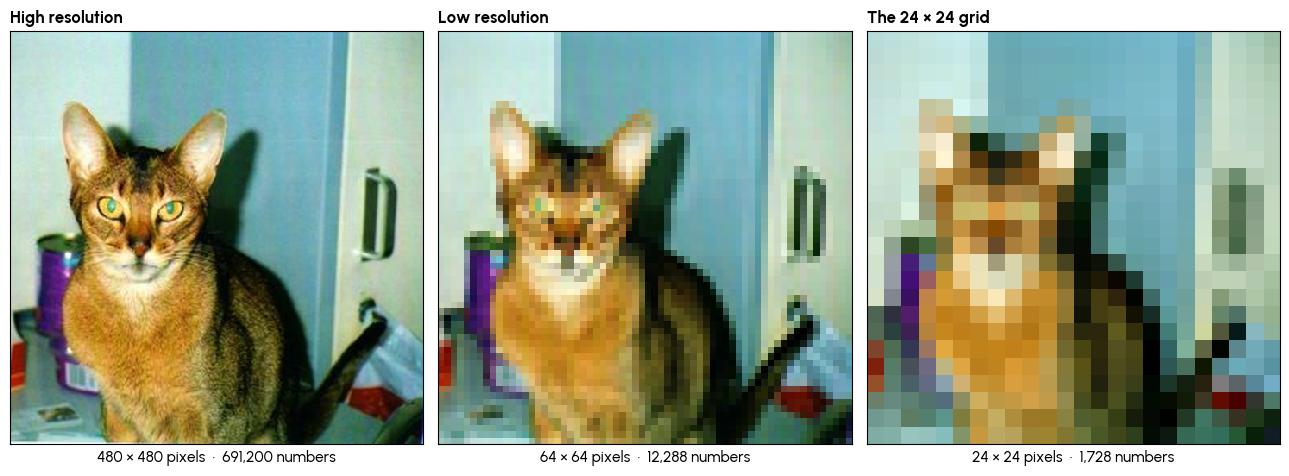

In [54]:
full = ImageOps.fit(Image.open(DATA / "oxford-iiit-pet/images/Abyssinian_119.jpg").convert("RGB"),
                    (480, 480), Image.LANCZOS, centering=(0.5, 0.38))

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, side, label in zip(axes, (480, 64, 24), ("High resolution", "Low resolution", "The 24 × 24 grid")):
    image = full if side == 480 else full.resize((side, side), Image.LANCZOS)
    ax.imshow(image, interpolation="nearest")                   # nearest: show every pixel as a square
    ax.set_title(label, loc="left", weight="bold")
    ax.set_xlabel(f"{side} × {side} pixels  ·  {3 * side * side:,} numbers", fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

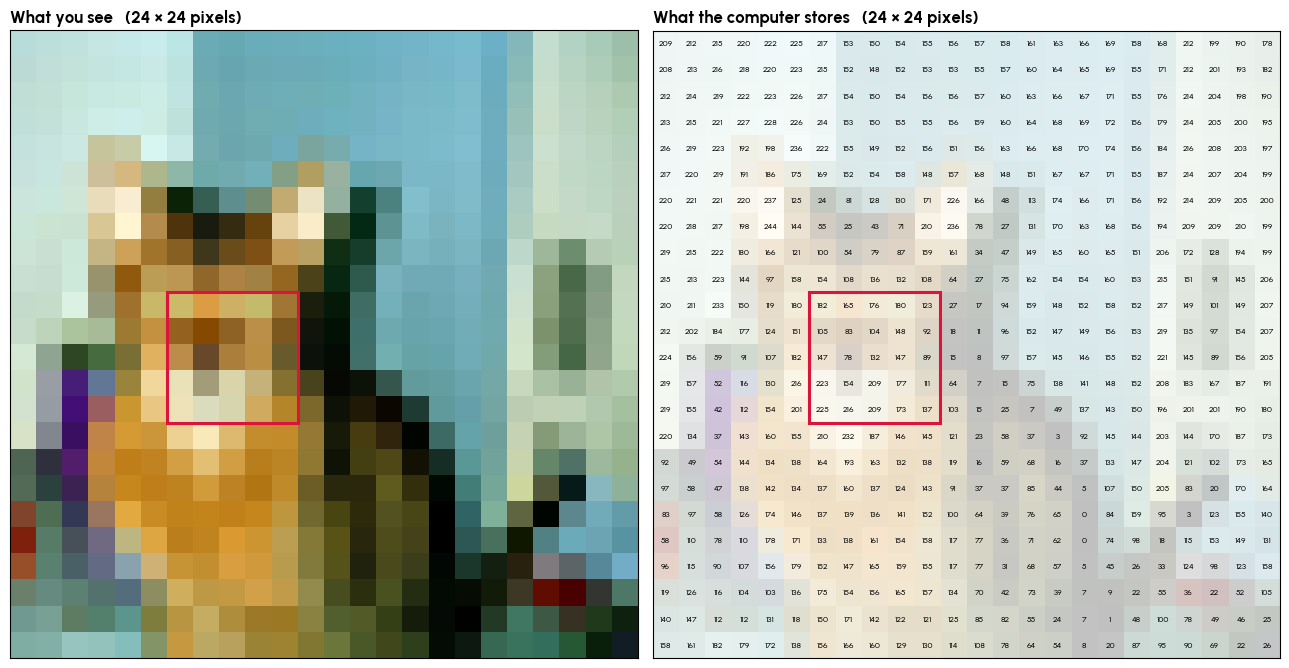

pixel (133, 73, 2)  ->  Y = 82.85, shown as 83


In [55]:
N, ZY, ZX, ZS = 24, 10, 6, 5                                    # grid, then the zoom window
full = ImageOps.fit(Image.open(DATA / "oxford-iiit-pet/images/Abyssinian_119.jpg").convert("RGB"),
                    (480, 480), Image.LANCZOS, centering=(0.5, 0.38))
px   = np.asarray(full.resize((N, N), Image.LANCZOS))
lum  = px @ [0.299, 0.587, 0.114]                               # perceived brightness

fig, (left, right) = plt.subplots(1, 2, figsize=(13, 6.9))
left.imshow(px, interpolation="nearest")
right.imshow(px, interpolation="nearest", alpha=0.25)
for i in range(N):
    for j in range(N):
        right.text(j, i, f"{lum[i, j]:.0f}", ha="center", va="center", fontsize=6)   # Urbanist digits run small
for ax, title in ((left, "What you see"), (right, "What the computer stores")):
    ax.add_patch(plt.Rectangle((ZX - .5, ZY - .5), ZS, ZS, fill=False, ec="crimson", lw=2.2))
    ax.set_title(f"{title}   ({N} × {N} pixels)", loc="left", weight="bold")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

print(f"pixel {tuple(int(v) for v in px[ZY + 1, ZX + 1])}  ->  Y = {lum[ZY + 1, ZX + 1]:.2f}, shown as {lum[ZY + 1, ZX + 1]:.0f}")

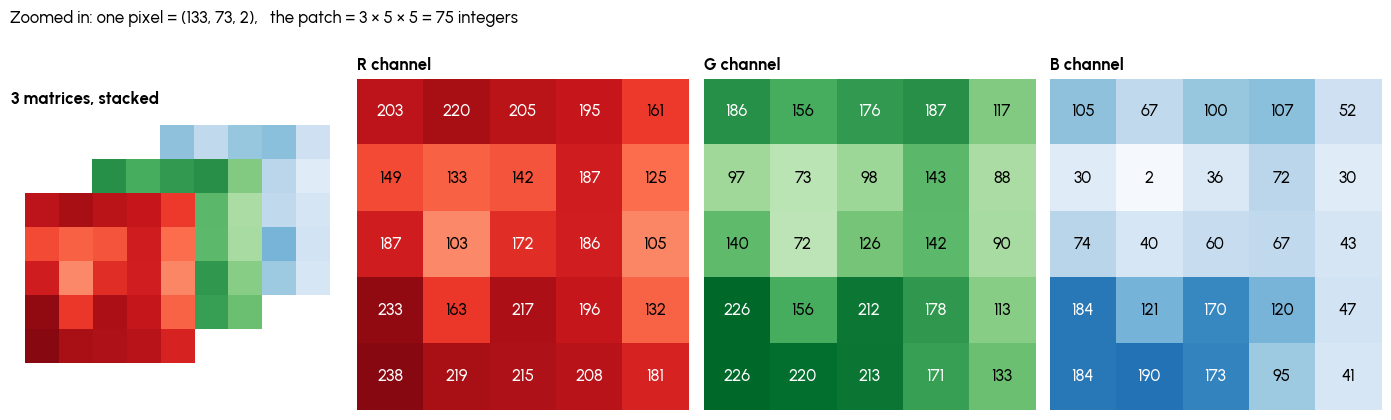

In [56]:
patch = px[ZY:ZY + ZS, ZX:ZX + ZS]                              # the red box, (5, 5, 3)

fig, axes = plt.subplots(1, 4, figsize=(14, 4.2))
for k, cmap in ((2, "Blues"), (1, "Greens"), (0, "Reds")):      # back to front
    axes[0].imshow(patch[..., k], cmap=cmap, vmin=0, vmax=255, zorder=3 - k,
                   extent=(2 * k, 2 * k + ZS, ZS - k, -k))
axes[0].set_xlim(-.4, ZS + 4.4); axes[0].set_ylim(ZS + .4, -2.4)
axes[0].set_title("3 matrices, stacked", loc="left", weight="bold")

for ax, k, cmap in zip(axes[1:], range(3), ("Reds", "Greens", "Blues")):
    ax.imshow(patch[..., k], cmap=cmap, vmin=0, vmax=255)
    for i in range(ZS):
        for j in range(ZS):
            ax.text(j, i, patch[i, j, k], ha="center", va="center", fontsize=12,
                    color="w" if patch[i, j, k] > 165 else "black")
    ax.set_title(f"{'RGB'[k]} channel", loc="left", weight="bold")

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines[:].set_visible(False)
fig.suptitle(f"Zoomed in: one pixel = {tuple(patch[1, 1])},   the patch = 3 × {ZS} × {ZS} "
             f"= {3 * ZS * ZS} integers", x=.01, y=1.02, ha="left", fontsize=12)
plt.tight_layout(); plt.show()

## 2. Images as tensors

**What a tensor is**

- A **tensor** is a block of numbers laid out along one or more directions, called **axes**
- Its **shape** lists how long each axis is
- A single number has shape `()`. A list of 2 numbers, `(2,)`. A grid of 176 rows and 176 columns, `(176, 176)`
- A colour photo is three grids stacked — **c**hannels, **h**eight, **w**idth: `(3, 176, 176)`
- Photos are processed 32 at a time, a **batch**, which adds one more axis in front: `(32, 3, 176, 176)`

**Step 1 · shrink 0–255 down to 0–1**

`ToTensor` divides every number by 255. For the red value of our pixel:

$$
\frac{133}{255} \;=\; 0.5216
$$

- Numbers near 0 and 1 are easier for a network to work with than numbers in the hundreds

**Step 2 · recentre each colour** — `Normalize`

The pretrained network learned from ImageNet photos. Across those, the average red value was 0.485, and red values typically sat about 0.229 either side of it. We rescale our photo so it speaks the same language:

$$
x' \;=\; \frac{x - \mu}{\sigma}
$$

- $x$ — one value after step 1
- $\mu$ (*mu*) — the **mean**: the average of that colour across ImageNet
- $\sigma$ (*sigma*) — the **standard deviation**: how far values typically sit from that average
- $x'$ — the result: *how many standard deviations above (+) or below (−) the ImageNet average*

| Channel | $\mu$ | $\sigma$ |
|:--|:--|:--|
| red | 0.485 | 0.229 |
| green | 0.456 | 0.224 |
| blue | 0.406 | 0.225 |

**Worked example** — the red value of our pixel

$$
x' \;=\; \frac{0.5216 - 0.485}{0.229} \;=\; \frac{0.0366}{0.229} \;=\; +0.16
$$

- **+0.16** — a touch redder than a typical ImageNet pixel
- Green gives $(0.2863 - 0.456)\,/\,0.224 = -0.76$ and blue gives $(0.0078 - 0.406)\,/\,0.225 = -1.77$ — far less blue than usual, which is exactly what dark orange is

In [57]:
normalise = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])   # μ and σ per channel
x = transforms.ToTensor()(full)

print(f"shape {tuple(x.shape)}  dtype {x.dtype}  range {x.min():.2f}..{x.max():.2f}")
print(f"batched {tuple(x[None].shape)}")

pixel = transforms.ToTensor()(Image.fromarray(px))[:, ZY + 1, ZX + 1]           # the worked-example pixel
print(f"\npixel as 0-255        {(pixel * 255).round().int().tolist()}")
print(f"step 1   ÷ 255        {[round(v, 4) for v in pixel.tolist()]}")
print(f"step 2   (x - μ) / σ  {[round(v, 2) for v in normalise(pixel[:, None, None]).flatten().tolist()]}")

shape (3, 480, 480)  dtype torch.float32  range 0.00..1.00
batched (1, 3, 480, 480)

pixel as 0-255        [133, 73, 2]
step 1   ÷ 255        [0.5216, 0.2863, 0.0078]
step 2   (x - μ) / σ  [0.16, -0.76, -1.77]


## 3. One convolutional layer

A convolutional layer does three things in a row. Each gets its own part below.

| Step | Name | In one sentence |
|:--|:--|:--|
| 1 | Convolution | slide a small grid of weights over the image, measuring how well each patch matches it |
| 2 | ReLU | throw away the negative results |
| 3 | Max pooling | shrink the result, keeping only the strongest response in each small area |

### 3.1 · Convolution

**The idea**

- A **kernel** (or *filter*) is a tiny grid of numbers — here 3 × 3
- Lay it on top of a 3 × 3 patch of the image
- Multiply each kernel number by the pixel directly underneath it
- Add up the nine results. That one number says *how much this patch looks like the pattern the kernel describes*

**Worked example — a kernel that looks for vertical edges**

$$
K \;=\; \begin{bmatrix} -1 & 0 & +1 \\ -2 & 0 & +2 \\ -1 & 0 & +1 \end{bmatrix}
$$

- Negative on the left, positive on the right: it rewards patches that are *dark on the left and bright on the right*

Patch A has a sharp edge — dark (10) on the left, bright (200) on the right:

$$
\begin{bmatrix} 10 & 10 & 200 \\ 10 & 10 & 200 \\ 10 & 10 & 200 \end{bmatrix}
\quad\longrightarrow\quad
\begin{aligned}
\text{row 1:}&\;\; (-1)(10) + (0)(10) + (1)(200) \;=\; 190 \\
\text{row 2:}&\;\; (-2)(10) + (0)(10) + (2)(200) \;=\; 380 \\
\text{row 3:}&\;\; (-1)(10) + (0)(10) + (1)(200) \;=\; 190
\end{aligned}
\quad\longrightarrow\quad
\mathbf{760}
$$

Patch B is flat — the same grey (50) everywhere. The nine kernel numbers add up to 0, so:

$$
(-1 + 0 + 1 \;-\; 2 + 0 + 2 \;-\; 1 + 0 + 1) \times 50 \;=\; 0 \times 50 \;=\; \mathbf{0}
$$

- A big number means *edge here*. Zero means *nothing here*
- Flip patch A — bright on the left, dark on the right — and the answer is **−760**: the opposite pattern

**Adding a bias**

- After the sum, add one more learned number $b$, the **bias**
- It shifts every result up or down, which sets how easily this kernel "switches on"

**Sliding**

- Repeat at every position, moving the kernel one pixel at a time
- Write each answer into a new grid, in the matching position. That grid is the **feature map** — a map of *where* the pattern appears
- The *same* nine weights are used everywhere, so a cat in the corner and a cat in the middle are found by the same kernel

**Colour images**

- A colour patch is 3 × 3 × 3: nine red, nine green and nine blue numbers
- So the kernel is 3 × 3 × 3 too — **27 weights** — plus 1 bias
- Multiply all 27 pairs, add them up, add the bias: still **one** number per position

**The formula** — everything above, in one line

$$
S(i,\,j) \;=\; b \;+\; \sum_{c}\;\sum_{u}\;\sum_{v}\; K(c,\,u,\,v)\;\cdot\;I\bigl(c,\; i+u,\; j+v\bigr)
$$

Read it from right to left:

- $I(c,\ i+u,\ j+v)$ — one number from the **input** image $I$: colour channel $c$, row $i+u$, column $j+v$
- $K(c,\ u,\ v)$ — the **kernel** weight lying on top of that number
- $u,\ v$ — the position *inside* the kernel: row $u$, column $v$, each 0, 1 or 2
- $i,\ j$ — where the kernel's top-left corner sits on the image; the answer goes in the same place in the output
- $\sum_c \sum_u \sum_v$ — "add up over every channel, every kernel row, every kernel column": all 27 products
- $b$ — the bias, added once
- $S(i,\ j)$ — the answer: one cell of the feature map

**Two extra settings: padding and stride**

- **Padding** $p$ — first surround the image with $p$ rings of zeros, so the kernel can also sit over the edges
- **Stride** $s$ — how many pixels the kernel jumps each move. $s = 1$ visits every position, $s = 2$ every other one
- Together they change $i + u$ into $i\,s + u - p$: jump by $s$, and shift back by the padding

$$
S(i,\,j) \;=\; b \;+\; \sum_{c}\;\sum_{u}\;\sum_{v}\; K(c,\,u,\,v)\;\cdot\;I\bigl(c,\; i\,s+u-p,\; j\,s+v-p\bigr)
$$

**How big is the feature map?** Count how many places the kernel fits along one side.

$$
H_{\text{out}} \;=\; \left\lfloor \frac{H + 2p - k}{s} \right\rfloor + 1
$$

- $H$ — input height; $k$ — kernel size; $H_{\text{out}}$ — output height. Width works the same way
- $H + 2p$ — the height once the padding is added
- $-\,k$ and $+\,1$ — a kernel $k$ tall fits in $(H + 2p - k) + 1$ positions
- $\div\, s$ — jumping $s$ pixels at a time visits only every $s$-th of them
- $\lfloor\ \rfloor$ — round down: a kernel that would hang off the edge doesn't count

| Input $H$ | Kernel $k$ | Padding $p$ | Stride $s$ | Working | Output |
|:--|:--|:--|:--|:--|:--|
| 5 | 3 | 0 | 1 | $\lfloor (5 + 0 - 3) / 1 \rfloor + 1$ | 3 |
| 5 | 3 | 1 | 1 | $\lfloor (5 + 2 - 3) / 1 \rfloor + 1$ | 5 |
| 5 | 3 | 1 | 2 | $\lfloor (5 + 2 - 3) / 2 \rfloor + 1$ | 3 |
| 176 | 7 | 3 | 2 | $\lfloor (176 + 6 - 7) / 2 \rfloor + 1$ | 88 — ResNet-18's first layer |

In [58]:
K_edge = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])        # the vertical-edge kernel
edge   = np.array([[10, 10, 200]] * 3)                         # patch A
flat   = np.full((3, 3), 50)                                    # patch B

print("patch A (edge)      ", (K_edge * edge).sum())            # multiply pair by pair, add up
print("patch A, flipped    ", (K_edge * edge[:, ::-1]).sum())
print("patch B (flat)      ", (K_edge * flat).sum())

size = lambda H, k, p, s: (H + 2 * p - k) // s + 1            # // divides, then rounds down
print("\noutput sizes        ", size(5, 3, 0, 1), size(5, 3, 1, 1), size(5, 3, 1, 2), size(176, 7, 3, 2))

patch A (edge)       760
patch A, flipped     -760
patch B (flat)       0

output sizes         3 5 3 88


**Watching one kernel work on the real photo**

- **Top row — one step.** The kernel sits on one 3 × 3 window of the cat, the orange box. Each pixel is multiplied by the weight on top of it, and the nine products are added up
- The answer, **507**, goes into the feature map at the centre of the window. With one ring of padding, every output cell lines up with the input pixel it was centred on
- 507 is large and positive because that window, on the inside edge of the cat's ear, is dark on the left and bright on the right — exactly what this kernel looks for
- **Bottom row — every step, four kernels.** Sliding the same kernel over all 4,096 positions builds the whole map. Four different kernels build four maps
- Before, each pixel was **one** number: its brightness. After, it is **four** numbers — how much vertical edge, horizontal edge, diagonal edge and bright spot surrounds it. Those four numbers are the pixel's coordinates in **feature space**
- At the ear: +507 for vertical edges, +1 for horizontal. The kernels agree this is a vertical edge, not a horizontal one
- A real network does the same thing with learned kernels instead of hand-made ones, and many more of them: ResNet-18's first layer has 64, so every position becomes 64 numbers

by hand: 507     F.conv2d: 507


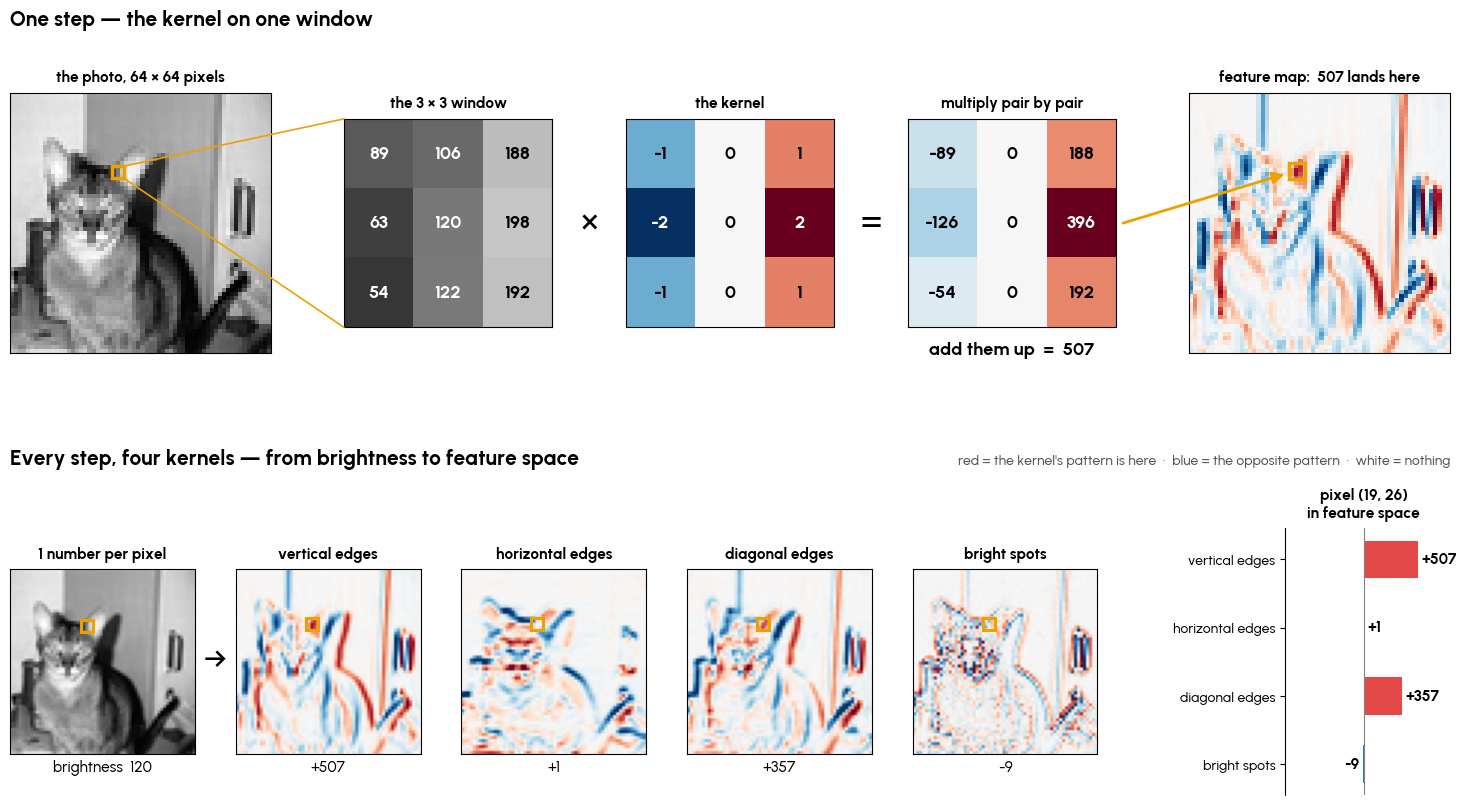

In [59]:
from matplotlib.patches import ConnectionPatch

KERNELS = {                                                     # four hand-made 3 x 3 kernels
    "vertical edges":   [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]],
    "horizontal edges": [[-1, -2, -1], [0, 0, 0], [1, 2, 1]],
    "diagonal edges":   [[-2, -1, 0], [-1, 0, 1], [0, 1, 2]],
    "bright spots":     [[0, -1, 0], [-1, 4, -1], [0, -1, 0]],
}
cat64 = np.asarray(full.convert("L").resize((64, 64), Image.LANCZOS), dtype=np.float32)    # brightness, 0-255
maps  = {name: F.conv2d(torch.from_numpy(cat64)[None, None], torch.tensor(k, dtype=torch.float32)[None, None],
                        padding=1)[0, 0].numpy() for name, k in KERNELS.items()}

row, col = 19, 26                                               # one spot on the cat
window   = cat64[row - 1:row + 2, col - 1:col + 2]              # the 3 x 3 patch under the kernel
weights  = np.array(KERNELS["vertical edges"])
products = weights * window                                     # multiply pair by pair
print(f"by hand: {products.sum():.0f}     F.conv2d: {maps['vertical edges'][row, col]:.0f}")

MARK = "#eda100"
def show_map(ax, m):                                            # skip the 1-pixel border the zero padding distorts
    inner = m[1:-1, 1:-1]; lim = np.percentile(np.abs(inner), 99)
    ax.imshow(inner, cmap="RdBu_r", vmin=-lim, vmax=lim, extent=(.5, 62.5, 62.5, .5))
def numbers(ax, M, cmap, lim, title):
    ax.imshow(M, cmap=cmap, vmin=0 if cmap == "gray" else -lim, vmax=lim)
    for (i, j), v in np.ndenumerate(M):
        dark = v < 140 if cmap == "gray" else abs(v) > .6 * lim
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=13, weight="bold",
                color="white" if dark else "black")
    ax.set_title(title, fontsize=11, weight="bold", pad=8)
    ax.set_xticks([]); ax.set_yticks([])

fig = plt.figure(figsize=(15, 8.6))
top = fig.add_gridspec(1, 5, width_ratios=[1.25, 1, 1, 1, 1.25], wspace=.32, left=.02, right=.98, top=.88, bottom=.55)
bot = fig.add_gridspec(1, 5, wspace=.22, left=.02, right=.745, top=.36, bottom=.05)
bar = fig.add_gridspec(1, 1, left=.87, right=.975, top=.36, bottom=.05)
a = [fig.add_subplot(top[k]) for k in range(5)]
b = [fig.add_subplot(bot[k]) for k in range(5)] + [fig.add_subplot(bar[0])]

# ---- top row: one position ---------------------------------------------------------------
a[0].imshow(cat64, cmap="gray")
a[0].add_patch(plt.Rectangle((col - 1.5, row - 1.5), 3, 3, fill=False, ec=MARK, lw=2.5))
a[0].set_title("the photo, 64 × 64 pixels", fontsize=11, weight="bold", pad=8)
a[0].set_xticks([]); a[0].set_yticks([])
numbers(a[1], window, "gray", 255, "the 3 × 3 window")
numbers(a[2], weights, "RdBu_r", 2, "the kernel")
numbers(a[3], products, "RdBu_r", np.abs(products).max(), "multiply pair by pair")
a[3].set_xlabel(f"add them up  =  {products.sum():.0f}", fontsize=13, weight="bold", labelpad=10)

show_map(a[4], maps["vertical edges"])
a[4].plot(col, row, "s", ms=11, mfc="none", mec=MARK, mew=2.5)
a[4].set_title(f"feature map:  {products.sum():.0f} lands here", fontsize=11, weight="bold", pad=8)
a[4].set_xticks([]); a[4].set_yticks([])

for corner in (-.5, 2.5):                                       # zoom lines, photo -> window
    fig.add_artist(ConnectionPatch((col + 1.5, row - 1.5 + 3 * (corner > 0)), (-.5, corner),
                                   a[0].transData, a[1].transData, color=MARK, lw=1.2))
for left, right, sym in ((a[1], a[2], "×"), (a[2], a[3], "=")):
    x = (left.get_position().x1 + right.get_position().x0) / 2
    fig.text(x, (left.get_position().y0 + left.get_position().y1) / 2, sym, ha="center", va="center", fontsize=26)
fig.add_artist(ConnectionPatch((2.6, 1), (col, row), a[3].transData, a[4].transData,
                               arrowstyle="-|>", mutation_scale=18, color=MARK, lw=2, shrinkB=9))

# ---- bottom row: every position, four kernels ----------------------------------------------
b[0].imshow(cat64, cmap="gray")
b[0].set_title("1 number per pixel", fontsize=11, weight="bold", pad=8)
b[0].set_xlabel(f"brightness  {cat64[row, col]:.0f}", fontsize=11)
values = []
for ax, (name, m) in zip(b[1:5], maps.items()):
    show_map(ax, m)
    ax.set_title(name, fontsize=11, weight="bold", pad=8)
    ax.set_xlabel(f"{m[row, col]:+.0f}", fontsize=11)
    values.append(m[row, col])
for ax in b[:5]:
    ax.plot(col, row, "s", ms=9, mfc="none", mec=MARK, mew=2.2)
    ax.set_xticks([]); ax.set_yticks([])

ax = b[5]
ax.barh(range(4)[::-1], values, color=["#e34948" if v > 0 else "#2a78d6" for v in values], height=.55)
ax.set_yticks(range(4)[::-1], list(maps))
ax.axvline(0, color="grey", lw=.8)
span = max(abs(v) for v in values) * 1.45
ax.set_xlim(-span, span); ax.set_xticks([])
for y, v in zip(range(4)[::-1], values):
    ax.text(v + (.04 if v >= 0 else -.04) * span, y, f"{v:+.0f}", va="center", ha="left" if v >= 0 else "right",
            fontsize=11, weight="bold")
ax.spines[["top", "right", "bottom"]].set_visible(False)
ax.set_title(f"pixel ({row}, {col})\nin feature space", fontsize=11, weight="bold", pad=8)

x = (b[0].get_position().x1 + b[1].get_position().x0) / 2
fig.text(x, (b[0].get_position().y0 + b[0].get_position().y1) / 2, "→", ha="center", va="center", fontsize=24)

fig.text(.02, .945, "One step — the kernel on one window", fontsize=15, weight="bold")
fig.text(.02, .435, "Every step, four kernels — from brightness to feature space", fontsize=15, weight="bold")
fig.text(.98, .435, "red = the kernel's pattern is here  ·  blue = the opposite pattern  ·  white = nothing",
         fontsize=10, ha="right", color="#52514e")
plt.show()

### 3.2 · ReLU

**The idea**

- Go through every number in the feature map
- If it is negative, replace it with 0. Otherwise, leave it alone

$$
\mathrm{ReLU}(x) \;=\; \max(0,\ x)
$$

- $\max(0,\ x)$ — "whichever is bigger: 0 or $x$"
- ReLU stands for *Rectified Linear Unit*; "rectified" means the negative half is cut off

**Worked example**

| $x$ | −3 | −0.5 | 0 | 2 | 7 |
|:--|:--|:--|:--|:--|:--|
| $\mathrm{ReLU}(x)$ | 0 | 0 | 0 | 2 | 7 |

**Why throw the negatives away?**

- A negative answer means *the opposite of the pattern is here* — for the edge kernel, bright on the left
- The layer only needs to report where its own pattern **is**. If the opposite matters, another kernel can learn to look for it
- It is also what makes depth worth having. Without a bend, layers of multiply-and-add collapse into one: doubling and then tripling is just multiplying by six, $2 \times (3 \times x) = 6x$. ReLU's corner at 0 is that bend

**Its slope — this matters for learning**

The **slope**, or *derivative*, of a function says how much its output changes when its input is nudged up a little.

$$
\frac{d}{dx}\,\mathrm{ReLU}(x) \;=\;
\begin{cases}
1 & \text{if } x > 0 \\
0 & \text{if } x \le 0
\end{cases}
$$

- $\frac{d}{dx}$ — read "the slope, as $x$ changes"
- Right of zero the line is diagonal: nudge $x$ up by 1 and the output goes up by 1, so the slope is **1**
- Left of zero the line is flat: nudge $x$ and the output stays 0, so the slope is **0**
- During training, learning signals pass straight through wherever a value was positive, and are blocked wherever it was not

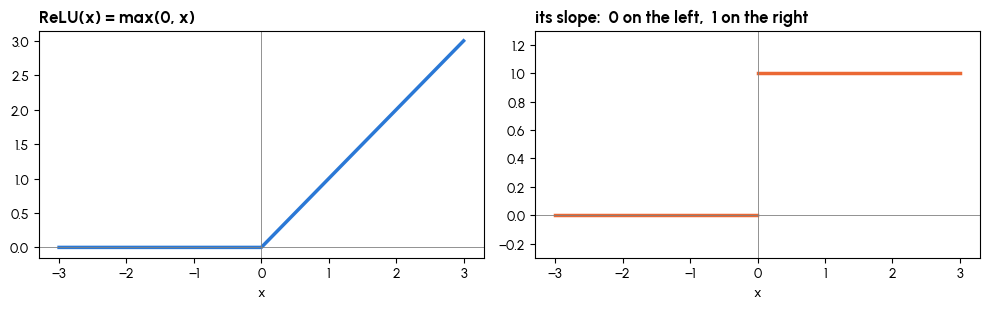

ReLU of [-3, -0.5, 0, 2, 7]  = [0.0, 0.0, 0.0, 2.0, 7.0]


In [60]:
xs = torch.linspace(-3, 3, 601)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.2))
ax1.plot(xs, F.relu(xs), color="#2a78d6", lw=2.5)
ax1.set_title("ReLU(x) = max(0, x)", loc="left", weight="bold")
ax2.plot(xs[xs < 0], torch.zeros_like(xs[xs < 0]), color="#eb6834", lw=2.5)
ax2.plot(xs[xs > 0], torch.ones_like(xs[xs > 0]), color="#eb6834", lw=2.5)
ax2.set_title("its slope:  0 on the left,  1 on the right", loc="left", weight="bold")
ax2.set_ylim(-.3, 1.3)
for ax in (ax1, ax2):
    ax.axhline(0, color="grey", lw=.6); ax.axvline(0, color="grey", lw=.6); ax.set_xlabel("x")
plt.tight_layout(); plt.show()

print("ReLU of [-3, -0.5, 0, 2, 7]  =", F.relu(torch.tensor([-3, -0.5, 0, 2, 7])).tolist())

### 3.3 · Max pooling

**The idea**

- Cut the feature map into small tiles that don't overlap — here 2 × 2
- From each tile, keep only the **largest** number
- The map ends up half as tall and half as wide: a quarter of the numbers

**Worked example** — a 4 × 4 feature map, cut into four 2 × 2 tiles

$$
\left[\begin{array}{cc|cc}
1 & 3 & 2 & 0 \\
5 & 2 & 1 & 1 \\ \hline
0 & 1 & 8 & 6 \\
2 & 4 & 3 & 7
\end{array}\right]
\quad\longrightarrow\quad
\begin{bmatrix} \max(1, 3, 5, 2) & \max(2, 0, 1, 1) \\ \max(0, 1, 2, 4) & \max(8, 6, 3, 7) \end{bmatrix}
\quad=\quad
\begin{bmatrix} 5 & 2 \\ 4 & 8 \end{bmatrix}
$$

**Why do it**

- It keeps the answer to *"was the pattern roughly here?"* and forgets *"at exactly which pixel?"* — nudge a whisker by one pixel and, most of the time, nothing changes
- A quarter of the numbers means a quarter of the work for the next layer
- The next layer's 3 × 3 kernel now covers a 6 × 6 area of the map before pooling, so deeper layers see bigger shapes
- Pooling has **no weights**. Nothing here is learned; it is a fixed rule

**The formula**

$$
P(i,\,j) \;=\; \max_{\substack{0 \,\le\, u \,<\, k \\ 0 \,\le\, v \,<\, k}}\; S\bigl(i\,s+u,\; j\,s+v\bigr)
$$

- $S$ — the feature map going in; $P$ — the smaller map coming out
- $k$ — the tile size, here 2; $s$ — the stride, also 2, so the tiles sit side by side without overlapping
- $u,\ v$ — the position inside a tile, each 0 or 1
- $\max$ — the largest of the $k \times k$ numbers in that tile
- The output size follows the same rule as convolution: $\lfloor (480 - 2) / 2 \rfloor + 1 = 240$

In [61]:
M = torch.tensor([[1, 3, 2, 0],
                  [5, 2, 1, 1],
                  [0, 1, 8, 6],
                  [2, 4, 3, 7]], dtype=torch.float32)

print(F.max_pool2d(M[None, None], kernel_size=2, stride=2)[0, 0].int().tolist())

[[5, 2], [4, 8]]


### 3.4 · All three, on the photo

- **Input** — the cat in greyscale, 480 × 480
- **Convolution** with the vertical-edge kernel — mid-grey where nothing happens, light and dark along edges
- **ReLU** — the dark, negative side of every edge disappears
- **Max pooling** — the same picture at 240 × 240
- The cell after the pictures checks the ReLU and pooling formulas against PyTorch's own versions

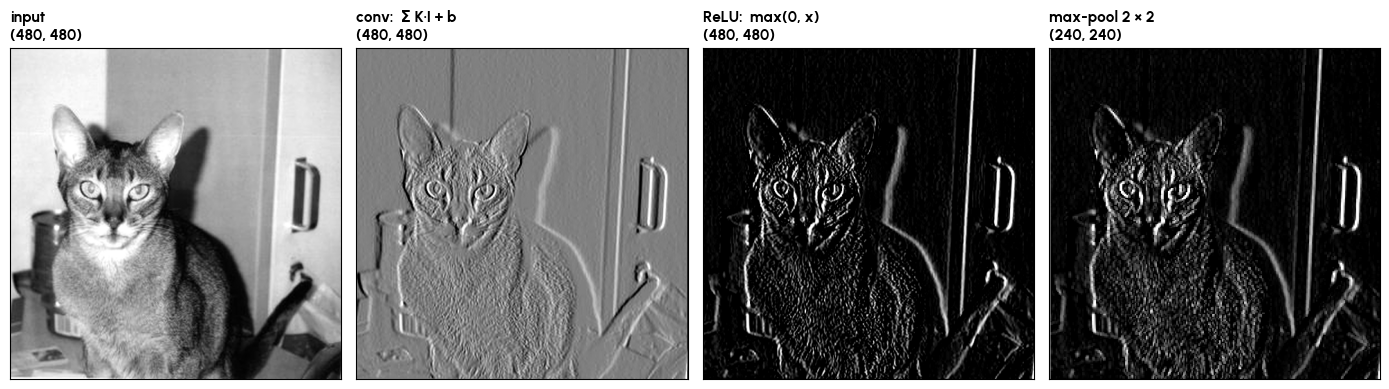

In [62]:
grey   = torch.from_numpy(np.asarray(full.convert("L"), np.float32) / 255)[None, None]
kernel = torch.tensor([[-1., 0, 1], [-2, 0, 2], [-1, 0, 1]])[None, None]         # vertical edges

conv = F.conv2d(grey, kernel, bias=torch.tensor([0.]), padding=1)
relu = F.relu(conv)
pool = F.max_pool2d(relu, 2)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, t, title in zip(axes, (grey, conv, relu, pool),
                        ("input", "conv:  Σ K·I + b", "ReLU:  max(0, x)", "max-pool 2 × 2")):
    a = t[0, 0].numpy()
    lim = np.percentile(np.abs(a), 99)                  # ignore a few extreme pixels
    ax.imshow(a, cmap="gray", vmin=-lim if a.min() < 0 else 0, vmax=lim)
    ax.set_title(f"{title}\n{tuple(t.shape[-2:])}", loc="left", fontsize=11, weight="bold")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

In [63]:
S = conv[0, 0].numpy()                                        # the feature map
R = np.maximum(0, S)                                          # ReLU, straight from the formula
H, W, k = *S.shape, 2
P = R.reshape(H // k, k, W // k, k).max(axis=(1, 3))          # max over each k x k window

print(f"ReLU     == F.relu         {np.allclose(R, relu[0, 0].numpy())}")
print(f"max-pool == F.max_pool2d   {np.allclose(P, pool[0, 0].numpy())}")
print(f"sizes  {S.shape} -> {P.shape}    (H + 2p - k)//s + 1 = {(H + 0 - k) // k + 1}")
print(f"ReLU zeroed {(S < 0).mean():.0%} of the map; pooling dropped {1 - P.size / S.size:.0%} of what was left")

ReLU     == F.relu         True
max-pool == F.max_pool2d   True
sizes  (480, 480) -> (240, 240)    (H + 2p - k)//s + 1 = 240
ReLU zeroed 48% of the map; pooling dropped 75% of what was left


## 4. From the formula to code, and how a kernel learns

**The formula, written as a loop** — the `convolve` function below

- `np.pad` adds the zeros first, which takes care of the $-\,p$
- Two loops walk over every output position $(i,\ j)$
- The slice `Ip[:, i*s : i*s+kh, j*s : j*s+kw]` grabs the whole window under the kernel at once — every $I(c,\ i\,s+u-p,\ j\,s+v-p)$
- `(K * window).sum()` multiplies pair by pair and adds up — the three $\sum$ signs
- `b +` adds the bias

**A footnote on the name**

- In pure maths, *convolution* flips the kernel upside down and left to right before sliding it. Neural-network libraries skip the flip — strictly, that is *cross-correlation*
- It makes no difference here: the kernel is learned, so if flipped numbers work better, it simply learns those

**How a kernel learns** — a preview of section 7

- Training asks, for every weight: *nudge this weight up a little — does the error go up or down, and by how much?* That amount is the weight's **gradient**
- One kernel weight $K(c,\,u,\,v)$ was used at **every** position of the image, so its total effect is the sum of its effects at each position:

$$
\frac{\partial L}{\partial K(c,u,v)} \;=\; \sum_{i}\sum_{j}\;
\underbrace{\frac{\partial L}{\partial S(i,j)}}_{\substack{\text{how much the error cares} \\ \text{about output cell } (i,\,j)}}
\;\cdot\;
\underbrace{I\bigl(c,\; i\,s+u-p,\; j\,s+v-p\bigr)}_{\substack{\text{the input number this weight} \\ \text{was multiplied by there}}}
$$

- $L$ — the **loss**, one number measuring how wrong the network is (section 8 shows how it is computed)
- $\partial$ — a curly "d": the slope with respect to one thing, while everything else is held still. $\frac{\partial L}{\partial K}$ reads "how much $L$ changes when $K$ is nudged"
- Why the input number? At that position the weight was multiplied by $I$, so nudging the weight moves the output by $I$ times the nudge
- A 3 × 3 × 3 kernel has 27 weights, and every one is trained on every patch of every image. That is how so few numbers learn so much

In [64]:
def convolve(I, K, b=0.0, stride=1, padding=0):
    """The equation above, as loops.  I: (C, H, W)   K: (C, kh, kw)."""
    C, H, W = I.shape
    _, kh, kw = K.shape
    Ip = np.pad(I, ((0, 0), (padding, padding), (padding, padding)))
    S = np.zeros(((H + 2 * padding - kh) // stride + 1, (W + 2 * padding - kw) // stride + 1))

    for i in range(S.shape[0]):
        for j in range(S.shape[1]):
            window = Ip[:, i * stride:i * stride + kh, j * stride:j * stride + kw]
            S[i, j] = b + (K * window).sum()
    return S

rng = np.random.default_rng(SEED)
I, K, b = rng.random((3, 12, 12)), rng.standard_normal((3, 3, 3)), 0.5
theirs = F.conv2d(torch.from_numpy(I)[None], torch.from_numpy(K)[None],
                  torch.tensor([b], dtype=torch.float64), padding=1)[0, 0].numpy()

print(f"my loops {convolve(I, K, b, padding=1).shape}  ==  F.conv2d {theirs.shape}"
      f"   max difference {np.abs(convolve(I, K, b, padding=1) - theirs).max():.1e}")

my loops (12, 12)  ==  F.conv2d (12, 12)   max difference 3.6e-15


## 5. Labels: 0 is cat, 1 is dog

- The label is just an index — the model never sees the words
- It emits **two numbers**; the larger one wins
- `trainval` is split into train and validation; the `test` split is kept back for section 9
- Two thirds of the photos are dogs, so *always guess dog* scores 68% — that is the bar

train 1600   val 600   test 3669 (held out)
trainval balance:  cats 1188   dogs 2492


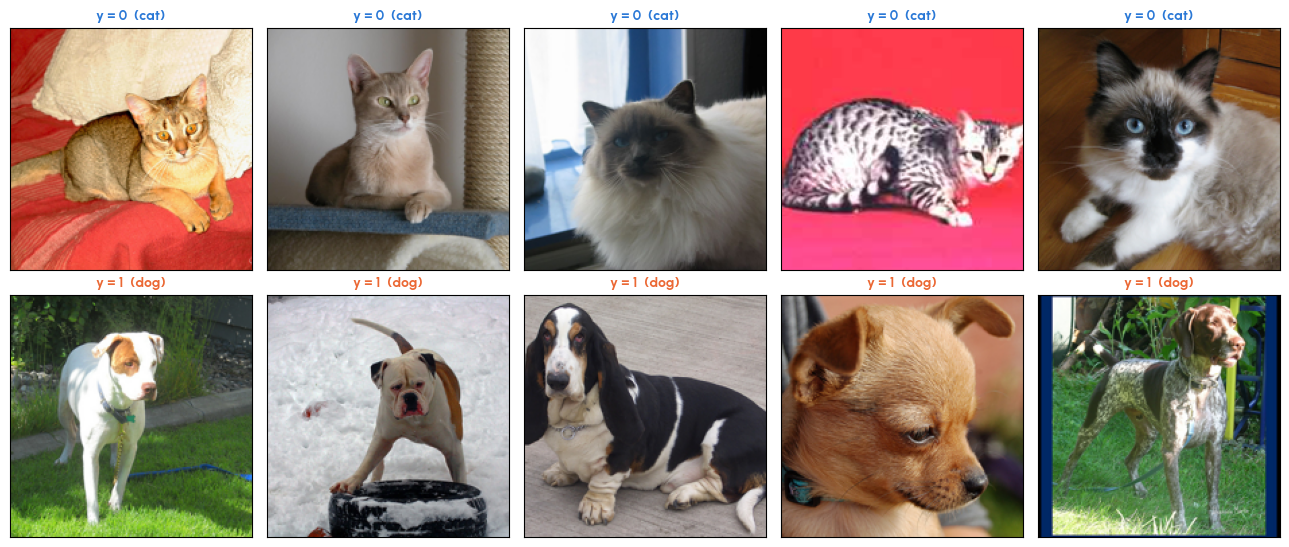

In [65]:
IMG_SIZE = 176
train_tf = transforms.Compose([transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0)),
                               transforms.RandomHorizontalFlip(), transforms.ToTensor(), normalise])
eval_tf  = transforms.Compose([transforms.Resize(202), transforms.CenterCrop(IMG_SIZE),
                               transforms.ToTensor(), normalise])

def pet_data(split, tf):
    return OxfordIIITPet(DATA, split=split, transform=tf, target_transform=to_binary)

N_TRAIN, N_VAL = 1600, 600
order    = torch.randperm(len(pets), generator=torch.Generator().manual_seed(SEED)).tolist()
train_ds = Subset(pet_data("trainval", train_tf), order[:N_TRAIN])
val_ds   = Subset(pet_data("trainval", eval_tf), order[N_TRAIN:N_TRAIN + N_VAL])
test_ds  = pet_data("test", eval_tf)

labels = np.array([to_binary(y) for y in pets._labels])
print(f"train {N_TRAIN}   val {N_VAL}   test {len(test_ds)} (held out)")
print(f"trainval balance:  cats {(labels == 0).sum()}   dogs {(labels == 1).sum()}")

fig, axes = plt.subplots(2, 5, figsize=(13, 5.6))
paths = np.array(pets._images)
for row, y in enumerate((0, 1)):
    for ax, p in zip(axes[row], paths[labels == y][[3, 40, 120, 260, 430]]):
        ax.imshow(ImageOps.fit(Image.open(p).convert("RGB"), (180, 180)))
        ax.set_title(f"y = {y}  ({CLASSES[y]})", fontsize=10,
                     color="#2a78d6" if y == 0 else "#eb6834", weight="bold")
        ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 6. The model

- ResNet-18 is a stack of *convolution → batch norm → ReLU* blocks, finished by one plain layer that outputs the two scores
- It was already trained on 1.28 million ImageNet photos, so its kernels already find edges, fur and eyes
- We freeze everything except `layer4` and `fc`, so the generic early kernels stay as they are

Three new pieces of maths live inside it.

**1 · Batch norm** — section 2's `Normalize`, done inside the network

- Between layers, numbers can drift very large or very small, which makes training unstable
- Batch norm recentres each channel using the average and spread of the **current batch** of photos, then applies two learned knobs

$$
\hat{x} \;=\; \gamma \cdot \frac{x - \mu_B}{\sqrt{\sigma_B^{2} + \epsilon}} \;+\; \beta
$$

- $\mu_B$ — the mean of this channel over the batch; $\sigma_B^{2}$ — its **variance**, the standard deviation squared
- $\epsilon$ (*epsilon*) — a tiny number, 0.00001, there only so we never divide by zero
- The fraction is exactly section 2's $(x - \mu)\,/\,\sigma$
- $\gamma$ (*gamma*) and $\beta$ (*beta*) — learned scale and shift. If recentring turns out to hurt, the network can learn to undo it

*Worked example* — three values $2,\ 4,\ 6$, with $\gamma = 2$ and $\beta = 1$

$$
\mu_B = \frac{2 + 4 + 6}{3} = 4
\qquad\qquad
\sigma_B = \sqrt{\frac{(2-4)^2 + (4-4)^2 + (6-4)^2}{3}} = \sqrt{\tfrac{8}{3}} = 1.633
$$

$$
\frac{x - 4}{1.633} \;=\; -1.22,\;\; 0,\;\; +1.22
\qquad\longrightarrow\qquad
2 \times (\ldots) + 1 \;=\; -1.45,\;\; 1,\;\; 3.45
$$

**2 · Global average pooling** — from maps to a list

- After `layer4` there are 512 feature maps, each 6 × 6
- Replace each map by its **average**: add its 36 numbers, divide by 36
- The result is a plain list of 512 numbers — *how much of each feature is in the photo overall*

$$
h_c \;=\; \frac{1}{H\,W}\sum_{i}\sum_{j} A(c,\,i,\,j)
$$

- $A(c,\ i,\ j)$ — map number $c$, row $i$, column $j$
- $H\,W$ — how many cells a map has, $6 \times 6 = 36$; $h_c$ — the average of map $c$

*Worked example* — a tiny 2 × 2 map

$$
\begin{bmatrix} 1 & 3 \\ 5 & 7 \end{bmatrix} \;\longrightarrow\; \frac{1 + 3 + 5 + 7}{4} \;=\; 4
$$

**3 · The head** — two weighted votes

- The last layer turns the 512 features into **two scores**: one for cat, one for dog
- Each score is a weighted sum: multiply every feature by its own weight, add them all up, add a bias

$$
z_{\text{cat}} \;=\; w_1 h_1 + w_2 h_2 + \cdots + w_{512}\, h_{512} + b_{\text{cat}}
$$

- A large positive weight means *this feature is evidence for cat*; a negative one, *evidence against*
- Dog has its own 512 weights and its own bias. Both scores at once, with the weights in a table $W$:

$$
z \;=\; W h + b
\qquad\qquad
W:\ 2 \times 512 \qquad h:\ 512 \qquad b:\ 2 \qquad z:\ 2
$$

*Worked example* — pretend there are only 3 features, $h = (2,\ 0,\ 1)$

$$
z_{\text{cat}} = (0.5)(2) + (-1)(0) + (2)(1) + 0.1 = 3.1
\qquad\qquad
z_{\text{dog}} = (-0.5)(2) + (1)(0) + (0.3)(1) + 0 = -0.7
$$

- Cat scores higher, so this photo would be called a cat
- The real head has $2 \times 512 + 2 = 1026$ brand-new weights; the rest of what we train is `layer4`, already pretrained

### The map of ResNet-18

- Read it left to right: the photo goes in, two scores come out
- **Hover** over any stage for a one-line summary, and **click** the sections under the map to open every layer
- Box height shows how big the picture still is — 176 × 176 at the start, a single number per feature by the end
- The curve over each `layer` is its **skip connection**, the "Res" in ResNet
- Orange stages are trained here, blue-grey stages stay frozen, grey stages have no weights at all

<div>
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 1000 350" width="100%" font-family="Urbanist, -apple-system, Segoe UI, sans-serif">
<rect x="1" y="1" width="998" height="348" rx="14" fill="#fcfcfb" stroke="#e4e2dc"/>
<text x="27.0" y="30" font-size="15" font-weight="700" fill="#1a1a1a">ResNet-18, stage by stage · hover over any stage</text>
<rect x="736.4" y="20" width="12" height="12" rx="3" fill="#f2f1ec" stroke="#a8a7a2"/>
<text x="754.4" y="30" font-size="11" fill="#5f5e5a">no weights</text>
<rect x="836.4" y="20" width="12" height="12" rx="3" fill="#dfe7f1" stroke="#6f89a8"/>
<text x="854.4" y="30" font-size="11" fill="#5f5e5a">frozen</text>
<rect x="911.6" y="20" width="12" height="12" rx="3" fill="#fde3d6" stroke="#eb6834"/>
<text x="929.6" y="30" font-size="11" fill="#5f5e5a">trained</text>
<line x1="110.0" y1="150" x2="117.0" y2="150" stroke="#b5b4ae" stroke-width="1.4"/><polygon points="122.0,150 116.0,146 116.0,154" fill="#b5b4ae"/>
<line x1="206.0" y1="150" x2="213.0" y2="150" stroke="#b5b4ae" stroke-width="1.4"/><polygon points="218.0,150 212.0,146 212.0,154" fill="#b5b4ae"/>
<line x1="302.0" y1="150" x2="309.0" y2="150" stroke="#b5b4ae" stroke-width="1.4"/><polygon points="314.0,150 308.0,146 308.0,154" fill="#b5b4ae"/>
<line x1="398.0" y1="150" x2="405.0" y2="150" stroke="#b5b4ae" stroke-width="1.4"/><polygon points="410.0,150 404.0,146 404.0,154" fill="#b5b4ae"/>
<line x1="494.0" y1="150" x2="501.0" y2="150" stroke="#b5b4ae" stroke-width="1.4"/><polygon points="506.0,150 500.0,146 500.0,154" fill="#b5b4ae"/>
<line x1="590.0" y1="150" x2="597.0" y2="150" stroke="#b5b4ae" stroke-width="1.4"/><polygon points="602.0,150 596.0,146 596.0,154" fill="#b5b4ae"/>
<line x1="686.0" y1="150" x2="693.0" y2="150" stroke="#b5b4ae" stroke-width="1.4"/><polygon points="698.0,150 692.0,146 692.0,154" fill="#b5b4ae"/>
<line x1="782.0" y1="150" x2="789.0" y2="150" stroke="#b5b4ae" stroke-width="1.4"/><polygon points="794.0,150 788.0,146 788.0,154" fill="#b5b4ae"/>
<line x1="878.0" y1="150" x2="885.0" y2="150" stroke="#b5b4ae" stroke-width="1.4"/><polygon points="890.0,150 884.0,146 884.0,154" fill="#b5b4ae"/>
<g opacity="1"><title>The photo: 3 colour channels × 176 × 176 pixels</title><rect x="27.0" y="40" width="82" height="236" fill="#fcfcfb"/><rect x="27.0" y="68.0" width="82" height="164.0" rx="7" fill="#f2f1ec" stroke="#a8a7a2" stroke-width="1.6"/>
<text x="68.0" y="55" text-anchor="middle" font-size="13" font-weight="700" fill="#1a1a1a">photo</text><text x="68.0" y="252" text-anchor="middle" font-size="11" fill="#1a1a1a">3 × 176 × 176</text><text x="68.0" y="268" text-anchor="middle" font-size="11" fill="#5f5e5a">no weights</text></g>
<g opacity="1"><title>conv1 → batch norm → ReLU · 64 kernels, each 7 × 7 × 3, stride 2 · 9,536 weights · frozen</title><rect x="123.0" y="40" width="82" height="236" fill="#fcfcfb"/><rect x="123.0" y="92.0" width="82" height="116.0" rx="7" fill="#dfe7f1" stroke="#6f89a8" stroke-width="1.6"/>
<text x="164.0" y="55" text-anchor="middle" font-size="13" font-weight="700" fill="#1a1a1a">conv1</text><text x="164.0" y="252" text-anchor="middle" font-size="11" fill="#1a1a1a">64 × 88 × 88</text><text x="164.0" y="268" text-anchor="middle" font-size="11" fill="#5f5e5a">9.5k</text></g>
<g opacity="1"><title>max-pool 3 × 3, stride 2 · halves height and width · no weights</title><rect x="219.0" y="40" width="82" height="236" fill="#fcfcfb"/><rect x="219.0" y="109.0" width="82" height="82.0" rx="7" fill="#f2f1ec" stroke="#a8a7a2" stroke-width="1.6"/>
<text x="260.0" y="55" text-anchor="middle" font-size="13" font-weight="700" fill="#1a1a1a">maxpool</text><text x="260.0" y="252" text-anchor="middle" font-size="11" fill="#1a1a1a">64 × 44 × 44</text><text x="260.0" y="268" text-anchor="middle" font-size="11" fill="#5f5e5a">no weights</text></g>
<g opacity="1"><title>layer1: 2 residual blocks, 64 → 64 channels · 147,968 weights · frozen</title><rect x="315.0" y="40" width="82" height="236" fill="#fcfcfb"/><rect x="315.0" y="109.0" width="82" height="82.0" rx="7" fill="#dfe7f1" stroke="#6f89a8" stroke-width="1.6"/>
<path d="M 323.0 109.0 Q 356.0 81.0 389.0 109.0" fill="none" stroke="#6f89a8" stroke-width="1.5"/>
<text x="356.0" y="55" text-anchor="middle" font-size="13" font-weight="700" fill="#1a1a1a">layer1</text><text x="356.0" y="252" text-anchor="middle" font-size="11" fill="#1a1a1a">64 × 44 × 44</text><text x="356.0" y="268" text-anchor="middle" font-size="11" fill="#5f5e5a">148k</text></g>
<g opacity="1"><title>layer2: 2 residual blocks, 64 → 128 channels, 44 × 44 → 22 × 22 · 525,568 weights · frozen</title><rect x="411.0" y="40" width="82" height="236" fill="#fcfcfb"/><rect x="411.0" y="121.0" width="82" height="58.0" rx="7" fill="#dfe7f1" stroke="#6f89a8" stroke-width="1.6"/>
<path d="M 419.0 121.0 Q 452.0 93.0 485.0 121.0" fill="none" stroke="#6f89a8" stroke-width="1.5"/>
<text x="452.0" y="55" text-anchor="middle" font-size="13" font-weight="700" fill="#1a1a1a">layer2</text><text x="452.0" y="252" text-anchor="middle" font-size="11" fill="#1a1a1a">128 × 22 × 22</text><text x="452.0" y="268" text-anchor="middle" font-size="11" fill="#5f5e5a">526k</text></g>
<g opacity="1"><title>layer3: 2 residual blocks, 128 → 256 channels, 22 × 22 → 11 × 11 · 2,099,712 weights · frozen</title><rect x="507.0" y="40" width="82" height="236" fill="#fcfcfb"/><rect x="507.0" y="129.5" width="82" height="41.0" rx="7" fill="#dfe7f1" stroke="#6f89a8" stroke-width="1.6"/>
<path d="M 515.0 129.5 Q 548.0 101.5 581.0 129.5" fill="none" stroke="#6f89a8" stroke-width="1.5"/>
<text x="548.0" y="55" text-anchor="middle" font-size="13" font-weight="700" fill="#1a1a1a">layer3</text><text x="548.0" y="252" text-anchor="middle" font-size="11" fill="#1a1a1a">256 × 11 × 11</text><text x="548.0" y="268" text-anchor="middle" font-size="11" fill="#5f5e5a">2.1M</text></g>
<g opacity="1"><title>layer4: 2 residual blocks, 256 → 512 channels, 11 × 11 → 6 × 6 · 8,393,728 weights · trained</title><rect x="603.0" y="40" width="82" height="236" fill="#fcfcfb"/><rect x="603.0" y="134.9" width="82" height="30.3" rx="7" fill="#fde3d6" stroke="#eb6834" stroke-width="1.6"/>
<path d="M 611.0 134.9 Q 644.0 106.9 677.0 134.9" fill="none" stroke="#eb6834" stroke-width="1.5"/>
<text x="644.0" y="55" text-anchor="middle" font-size="13" font-weight="700" fill="#1a1a1a">layer4</text><text x="644.0" y="252" text-anchor="middle" font-size="11" fill="#1a1a1a">512 × 6 × 6</text><text x="644.0" y="268" text-anchor="middle" font-size="11" fill="#5f5e5a">8.4M</text></g>
<g opacity="1"><title>average each 6 × 6 map into one number · 512 × 6 × 6 → 512 · no weights</title><rect x="699.0" y="40" width="82" height="236" fill="#fcfcfb"/><rect x="699.0" y="137.0" width="82" height="26.0" rx="7" fill="#f2f1ec" stroke="#a8a7a2" stroke-width="1.6"/>
<text x="740.0" y="55" text-anchor="middle" font-size="13" font-weight="700" fill="#1a1a1a">avgpool</text><text x="740.0" y="252" text-anchor="middle" font-size="11" fill="#1a1a1a">512</text><text x="740.0" y="268" text-anchor="middle" font-size="11" fill="#5f5e5a">no weights</text></g>
<g opacity="1"><title>the head: 512 features → 2 scores · 1,026 weights · trained</title><rect x="795.0" y="40" width="82" height="236" fill="#fcfcfb"/><rect x="795.0" y="137.0" width="82" height="26.0" rx="7" fill="#fde3d6" stroke="#eb6834" stroke-width="1.6"/>
<text x="836.0" y="55" text-anchor="middle" font-size="13" font-weight="700" fill="#1a1a1a">fc</text><text x="836.0" y="252" text-anchor="middle" font-size="11" fill="#1a1a1a">2</text><text x="836.0" y="268" text-anchor="middle" font-size="11" fill="#5f5e5a">1.0k</text></g>
<g opacity="1"><title>the two scores, cat and dog · softmax turns them into probabilities</title><rect x="891.0" y="40" width="82" height="236" fill="#fcfcfb"/><rect x="891.0" y="137.0" width="82" height="26.0" rx="7" fill="#f2f1ec" stroke="#a8a7a2" stroke-width="1.6"/>
<text x="932.0" y="55" text-anchor="middle" font-size="13" font-weight="700" fill="#1a1a1a">2 scores</text><text x="932.0" y="252" text-anchor="middle" font-size="11" fill="#1a1a1a">cat, dog</text><text x="932.0" y="268" text-anchor="middle" font-size="11" fill="#5f5e5a">no weights</text></g>
<text x="27.0" y="294" font-size="11" fill="#5f5e5a">where the 11,177,538 weights live</text>
<g><title>conv1 + bn1 · 9,536 weights · 0.1%</title><rect x="27.0" y="301" width="0.8" height="16" fill="#d4deea" stroke="#fcfcfb" stroke-width=".8"/></g>
<g><title>layer1 · 147,968 weights · 1.3%</title><rect x="27.8" y="301" width="12.5" height="16" fill="#bccbdc" stroke="#fcfcfb" stroke-width=".8"/></g>
<g><title>layer2 · 525,568 weights · 4.7%</title><rect x="40.3" y="301" width="44.5" height="16" fill="#a5b8cf" stroke="#fcfcfb" stroke-width=".8"/></g>
<g><title>layer3 · 2,099,712 weights · 18.8%</title><rect x="84.8" y="301" width="177.7" height="16" fill="#8ea5c2" stroke="#fcfcfb" stroke-width=".8"/></g>
<text x="258.5" y="335" text-anchor="end" font-size="11" fill="#1a1a1a">layer3 · 18.8%</text>
<g><title>layer4 · 8,393,728 weights · 75.1%</title><rect x="262.5" y="301" width="710.4" height="16" fill="#eb6834" stroke="#fcfcfb" stroke-width=".8"/></g>
<text x="617.7" y="335" text-anchor="middle" font-size="11" fill="#1a1a1a">layer4 · 75.1% · trained</text>
<g><title>fc · 1,026 weights · 0.0%</title><rect x="972.9" y="301" width="0.6" height="16" fill="#eb6834" stroke="#fcfcfb" stroke-width=".8"/></g>
<text x="27.0" y="335" font-size="11" fill="#1a1a1a">conv1 → layer2 · 6.1%</text>
</svg>
</div>

<details><summary><b>The residual block</b> — the unit every <code>layer</code> is built from</summary>

- Each `layer` is 2 **residual blocks**. A block does: 3 × 3 conv → batch norm → ReLU → 3 × 3 conv → batch norm → **add the block's own input back** → ReLU
- In symbols: $y = \mathrm{ReLU}\bigl(F(x) + x\bigr)$, where $F$ is the conv–norm–ReLU–conv–norm stack
- If a block has nothing useful to add, it can learn $F(x) \approx 0$ and pass the picture through unchanged. That is what lets very deep networks train well
- When a block shrinks the picture and doubles the channels, the skip path gets a 1 × 1 conv with stride 2, so the two can still be added

</details>

<details><summary><b>Counting the weights</b> — how 11,177,538 adds up</summary>

- A conv layer with $C_{\text{out}}$ kernels, each $C_{\text{in}} \times k \times k$, has $C_{\text{out}} \times C_{\text{in}} \times k \times k$ weights. ResNet's convs have no bias
- Example from `layer1`: $64 \times 64 \times 3 \times 3 = 36,864$
- Batch norm has one $\gamma$ and one $\beta$ per channel: $2 \times C$
- The head has $512 \times 2$ weights plus 2 biases: $1,026$
- Doubling the channels in *and* out makes a conv four times bigger, which is why `layer4` alone holds 75.1% of the network

</details>

<details><summary><b>photo → conv1 → maxpool</b> · 3 × 176 × 176 → 64 × 44 × 44 · 9,536 weights · frozen</summary>

| layer | what it does | output | weights |
|:--|:--|:--|--:|
| `conv1` | 64 kernels, 7 × 7 × 3, stride 2, padding 3 | 64 × 88 × 88 | 9,408 |
| `bn1` | batch norm | 64 × 88 × 88 | 128 |
| `relu` | negatives become 0 | 64 × 88 × 88 | 0 |
| `maxpool` | 3 × 3 tiles, stride 2, padding 1 | 64 × 44 × 44 | 0 |

- Sizes from section 3.1's formula: $\lfloor (176 + 6 - 7) / 2 \rfloor + 1 = 88$, then $\lfloor (88 + 2 - 3) / 2 \rfloor + 1 = 44$

</details>

<details><summary><b>layer1</b> · 64 × 44 × 44 → 64 × 44 × 44 · 147,968 weights · frozen</summary>

<details><summary>block 0 · 73,984 weights</summary>

| layer | what it does | output | weights |
|:--|:--|:--|--:|
| `conv1` | 64 kernels, 3 × 3 × 64 | 64 × 44 × 44 | 36,864 |
| `bn1` | batch norm, then ReLU | 64 × 44 × 44 | 128 |
| `conv2` | 64 kernels, 3 × 3 × 64 | 64 × 44 × 44 | 36,864 |
| `bn2` | batch norm | 64 × 44 × 44 | 128 |
| skip | add the block's input back, then ReLU | 64 × 44 × 44 | 0 |

</details>

<details><summary>block 1 · 73,984 weights</summary>

| layer | what it does | output | weights |
|:--|:--|:--|--:|
| `conv1` | 64 kernels, 3 × 3 × 64 | 64 × 44 × 44 | 36,864 |
| `bn1` | batch norm, then ReLU | 64 × 44 × 44 | 128 |
| `conv2` | 64 kernels, 3 × 3 × 64 | 64 × 44 × 44 | 36,864 |
| `bn2` | batch norm | 64 × 44 × 44 | 128 |
| skip | add the block's input back, then ReLU | 64 × 44 × 44 | 0 |

</details>

</details>

<details><summary><b>layer2</b> · 64 × 44 × 44 → 128 × 22 × 22 · 525,568 weights · frozen</summary>

<details><summary>block 0 · 230,144 weights</summary>

| layer | what it does | output | weights |
|:--|:--|:--|--:|
| `conv1` | 128 kernels, 3 × 3 × 64, stride 2 | 128 × 22 × 22 | 73,728 |
| `bn1` | batch norm, then ReLU | 128 × 22 × 22 | 256 |
| `conv2` | 128 kernels, 3 × 3 × 128 | 128 × 22 × 22 | 147,456 |
| `bn2` | batch norm | 128 × 22 × 22 | 256 |
| skip | 1 × 1 conv (128 kernels × 64, stride 2) and batch norm, so the input fits; then add, then ReLU | 128 × 22 × 22 | 8,448 |

</details>

<details><summary>block 1 · 295,424 weights</summary>

| layer | what it does | output | weights |
|:--|:--|:--|--:|
| `conv1` | 128 kernels, 3 × 3 × 128 | 128 × 22 × 22 | 147,456 |
| `bn1` | batch norm, then ReLU | 128 × 22 × 22 | 256 |
| `conv2` | 128 kernels, 3 × 3 × 128 | 128 × 22 × 22 | 147,456 |
| `bn2` | batch norm | 128 × 22 × 22 | 256 |
| skip | add the block's input back, then ReLU | 128 × 22 × 22 | 0 |

</details>

</details>

<details><summary><b>layer3</b> · 128 × 22 × 22 → 256 × 11 × 11 · 2,099,712 weights · frozen</summary>

<details><summary>block 0 · 919,040 weights</summary>

| layer | what it does | output | weights |
|:--|:--|:--|--:|
| `conv1` | 256 kernels, 3 × 3 × 128, stride 2 | 256 × 11 × 11 | 294,912 |
| `bn1` | batch norm, then ReLU | 256 × 11 × 11 | 512 |
| `conv2` | 256 kernels, 3 × 3 × 256 | 256 × 11 × 11 | 589,824 |
| `bn2` | batch norm | 256 × 11 × 11 | 512 |
| skip | 1 × 1 conv (256 kernels × 128, stride 2) and batch norm, so the input fits; then add, then ReLU | 256 × 11 × 11 | 33,280 |

</details>

<details><summary>block 1 · 1,180,672 weights</summary>

| layer | what it does | output | weights |
|:--|:--|:--|--:|
| `conv1` | 256 kernels, 3 × 3 × 256 | 256 × 11 × 11 | 589,824 |
| `bn1` | batch norm, then ReLU | 256 × 11 × 11 | 512 |
| `conv2` | 256 kernels, 3 × 3 × 256 | 256 × 11 × 11 | 589,824 |
| `bn2` | batch norm | 256 × 11 × 11 | 512 |
| skip | add the block's input back, then ReLU | 256 × 11 × 11 | 0 |

</details>

</details>

<details><summary><b>layer4</b> · 256 × 11 × 11 → 512 × 6 × 6 · 8,393,728 weights · trained</summary>

<details><summary>block 0 · 3,673,088 weights</summary>

| layer | what it does | output | weights |
|:--|:--|:--|--:|
| `conv1` | 512 kernels, 3 × 3 × 256, stride 2 | 512 × 6 × 6 | 1,179,648 |
| `bn1` | batch norm, then ReLU | 512 × 6 × 6 | 1,024 |
| `conv2` | 512 kernels, 3 × 3 × 512 | 512 × 6 × 6 | 2,359,296 |
| `bn2` | batch norm | 512 × 6 × 6 | 1,024 |
| skip | 1 × 1 conv (512 kernels × 256, stride 2) and batch norm, so the input fits; then add, then ReLU | 512 × 6 × 6 | 132,096 |

</details>

<details><summary>block 1 · 4,720,640 weights</summary>

| layer | what it does | output | weights |
|:--|:--|:--|--:|
| `conv1` | 512 kernels, 3 × 3 × 512 | 512 × 6 × 6 | 2,359,296 |
| `bn1` | batch norm, then ReLU | 512 × 6 × 6 | 1,024 |
| `conv2` | 512 kernels, 3 × 3 × 512 | 512 × 6 × 6 | 2,359,296 |
| `bn2` | batch norm | 512 × 6 × 6 | 1,024 |
| skip | add the block's input back, then ReLU | 512 × 6 × 6 | 0 |

</details>

</details>

<details><summary><b>avgpool → fc</b> · 512 × 6 × 6 → 2 · 1,026 weights · trained</summary>

| layer | what it does | output | weights |
|:--|:--|:--|--:|
| `avgpool` | average each 6 × 6 map into one number | 512 | 0 |
| `fc` | 2 weighted sums of the 512 features | 2 | 1,026 |

</details>

In [66]:
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 2)
for name, p in model.named_parameters():
    p.requires_grad_(name.startswith(("layer4", "fc")))
model = model.to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"{trainable:,} trainable of {total:,} parameters ({trainable / total:.0%})")

8,394,754 trainable of 11,177,538 parameters (75%)


## 7. How the network learns

**The loss — one number for "how wrong"**

- After a photo goes through the network, the prediction is compared with the true label and boiled down to a single number, the **loss** $L$
- $L = 0$ is perfect; bigger is worse. Training means nothing more than making $L$ small
- Section 8 shows exactly how $L$ is worked out

**The gradient — which way is downhill?**

- Picture the loss as a hilly landscape, with one direction for each of the 8.4 million weights we train. We want the lowest valley
- A weight's **gradient** is the slope of that landscape in its direction: *nudge this weight up a little — how much does the loss change?*
- A positive gradient means raising the weight raises the loss, so **lower** it. A negative gradient means **raise** it

**Gradient descent — a small step downhill**

$$
w_{\text{new}} \;=\; w \;-\; \eta \cdot \frac{\partial L}{\partial w}
$$

- $w$ — one weight; $\frac{\partial L}{\partial w}$ — its gradient
- $\eta$ (*eta*) — the **learning rate**: how big a step to take. Here $\eta = 0.0003$
- The minus sign is what makes it go *down*hill

*Worked example* — a made-up loss with just one weight, $L(w) = (w - 3)^2$. The best weight is clearly 3, but pretend we don't know. Start at $w = 5$ with $\eta = 0.1$:

- **Loss now** — $L(5) = (5 - 3)^2 = 4$
- **Slope** — for $(w - 3)^2$ the slope is $2(w - 3)$, a standard calculus rule, so $2 \times (5 - 3) = 4$. Positive, so move left
- **Step** — $w_{\text{new}} = 5 - 0.1 \times 4 = 4.6$
- **Loss after** — $L(4.6) = (4.6 - 3)^2 = 2.56$. Lower
- Repeat, and $w$ creeps towards 3. A real network does exactly this, for millions of weights at once

**The chain rule — passing blame backwards**

- The loss doesn't depend on an early weight directly; it depends on it *through* every layer in between
- The **chain rule** says: to get the overall slope, multiply the slopes of each link in the chain

$$
\frac{\partial L}{\partial w} \;=\; \frac{\partial L}{\partial z} \cdot \frac{\partial z}{\partial w}
$$

- Read it as *(how much $L$ moves per unit of $z$)* × *(how much $z$ moves per unit of $w$)*

*Worked example* — two links, $z = 3w$ and then $L = z^2$, at $w = 1$ (so $z = 3$)

$$
\frac{\partial z}{\partial w} = 3
\qquad\qquad
\frac{\partial L}{\partial z} = 2z = 6
\qquad\qquad
\frac{\partial L}{\partial w} = 6 \times 3 = 18
$$

- **Backpropagation** is just the chain rule applied layer by layer, starting at the loss and walking back to the first layer. PyTorch does all of it in one line, `loss.backward()`

**Where the walk backwards starts**

For the loss we use (section 8), the slope with respect to the two scores comes out remarkably simple:

$$
\frac{\partial L}{\partial z_k} \;=\; p_k - y_k
$$

- $p_k$ — the probability the model gave class $k$; $y_k$ — the truth: 1 for the correct class, 0 for the other
- *Right and fairly sure* — a cat with $p = (0.9,\ 0.1)$ and $y = (1,\ 0)$ gives $(-0.1,\ +0.1)$: a gentle nudge to raise cat and lower dog
- *Wrong and sure* — $p = (0.2,\ 0.8)$ gives $(-0.8,\ +0.8)$: a hard shove in the same direction

**AdamW — a smarter step**

Plain gradient descent uses the raw slope. AdamW, the optimiser we train with, smooths it first.

- $g$ — this step's gradient
- $m$ — a running average of recent gradients, called **momentum**. A steady direction builds up speed; noisy back-and-forth cancels out

$$
m_{\text{new}} \;=\; 0.9\, m \;+\; 0.1\, g
$$

- $v$ — a running average of *squared* gradients: roughly how big this weight's gradients usually are

$$
v_{\text{new}} \;=\; 0.999\, v \;+\; 0.001\, g^{2}
$$

- The step divides one by the square root of the other, so every weight moves a sensible amount whether its gradients are huge or tiny

$$
w_{\text{new}} \;=\; w \;-\; \eta \left( \frac{\hat{m}}{\sqrt{\hat{v}} + \epsilon} \;+\; \lambda\, w \right)
$$

- $\hat{m},\ \hat{v}$ — the same two averages, corrected for having started at zero
- $\lambda$ (*lambda*) — **weight decay**, here 0.0001: a gentle pull of every weight towards zero, which discourages memorising
- One neat consequence: on the very first step, every weight moves by almost exactly $\eta$, whether its gradient was 4 or 0.001

**Epoch**

- One **epoch** is one full pass over the training set
- Photos are served in batches of 32; each batch is one forward pass, one backward pass, one update
- Here that is 1600 / 32 = 50 updates per epoch

**Hyperparameters** — the settings we choose, rather than learn

| Setting | Controls | If it is wrong |
|:--|:--|:--|
| learning rate $\eta$ | step size | too high: the loss blows up · too low: nothing moves |
| batch size | photos per update | small: noisy steps · large: needs more memory |
| epochs | passes over the data | too few: underfits · too many: memorises |
| weight decay $\lambda$ | pull towards zero | too high: underfits |
| frozen layers | how much of the backbone adapts | unfreeze everything on small data and it memorises |
| augmentation | random flips and crops | none: memorises the training photos |

- A falling training loss only proves the network can memorise. **Validation** accuracy, on photos it never trains on, is the honest signal

### The same map, running backwards

- The loss now sits at the right-hand end. The orange arrows are the backward pass: each stage hands a gradient to the stage before it
- The number under each arrow is the gradient's shape at that point
- **Hover** over a stage to see what gradient reaches it and what it does with it
- Faded stages are frozen. PyTorch never computes a gradient for them, which saves a lot of work
- The strip at the bottom shows which of the 11,177,538 weights actually get updated

<div>
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 1000 350" width="100%" font-family="Urbanist, -apple-system, Segoe UI, sans-serif">
<rect x="1" y="1" width="998" height="348" rx="14" fill="#fcfcfb" stroke="#e4e2dc"/>
<text x="27.0" y="30" font-size="15" font-weight="700" fill="#1a1a1a">The same map, backwards · the gradient flows from the loss to every weight we train</text>
<line x1="695.4" y1="26" x2="717.4" y2="26" stroke="#eb6834" stroke-width="2.4"/><polygon points="691.4,26 698.4,22 698.4,30" fill="#eb6834"/>
<text x="723.4" y="30" font-size="11" fill="#5f5e5a">gradient</text>
<rect x="793.0" y="20" width="12" height="12" rx="3" fill="#fde3d6" stroke="#eb6834"/>
<text x="811.0" y="30" font-size="11" fill="#5f5e5a">trained</text>
<rect x="874.4" y="20" width="12" height="12" rx="3" fill="#dfe7f1" stroke="#6f89a8"/>
<text x="892.4" y="30" font-size="11" fill="#5f5e5a">frozen, faded</text>
<line x1="110.0" y1="150" x2="117.0" y2="150" stroke="#d9d8d2" stroke-width="1.4"/><polygon points="122.0,150 116.0,146 116.0,154" fill="#d9d8d2"/>
<line x1="206.0" y1="150" x2="213.0" y2="150" stroke="#d9d8d2" stroke-width="1.4"/><polygon points="218.0,150 212.0,146 212.0,154" fill="#d9d8d2"/>
<line x1="302.0" y1="150" x2="309.0" y2="150" stroke="#d9d8d2" stroke-width="1.4"/><polygon points="314.0,150 308.0,146 308.0,154" fill="#d9d8d2"/>
<line x1="398.0" y1="150" x2="405.0" y2="150" stroke="#d9d8d2" stroke-width="1.4"/><polygon points="410.0,150 404.0,146 404.0,154" fill="#d9d8d2"/>
<line x1="494.0" y1="150" x2="501.0" y2="150" stroke="#d9d8d2" stroke-width="1.4"/><polygon points="506.0,150 500.0,146 500.0,154" fill="#d9d8d2"/>
<line x1="590.0" y1="150" x2="597.0" y2="150" stroke="#d9d8d2" stroke-width="1.4"/><polygon points="602.0,150 596.0,146 596.0,154" fill="#d9d8d2"/>
<line x1="686.0" y1="150" x2="693.0" y2="150" stroke="#d9d8d2" stroke-width="1.4"/><polygon points="698.0,150 692.0,146 692.0,154" fill="#d9d8d2"/>
<line x1="782.0" y1="150" x2="789.0" y2="150" stroke="#d9d8d2" stroke-width="1.4"/><polygon points="794.0,150 788.0,146 788.0,154" fill="#d9d8d2"/>
<line x1="878.0" y1="150" x2="885.0" y2="150" stroke="#d9d8d2" stroke-width="1.4"/><polygon points="890.0,150 884.0,146 884.0,154" fill="#d9d8d2"/>
<g opacity="0.38"><title>The photo · never receives a gradient</title><rect x="27.0" y="40" width="82" height="236" fill="#fcfcfb"/><rect x="27.0" y="68.0" width="82" height="164.0" rx="7" fill="#f2f1ec" stroke="#a8a7a2" stroke-width="1.6"/>
<text x="68.0" y="55" text-anchor="middle" font-size="13" font-weight="700" fill="#1a1a1a">photo</text><text x="68.0" y="252" text-anchor="middle" font-size="11" fill="#1a1a1a">3 × 176 × 176</text><text x="68.0" y="268" text-anchor="middle" font-size="11" fill="#5f5e5a">no weights</text></g>
<g opacity="0.38"><title>conv1 → batch norm → ReLU · 64 kernels, each 7 × 7 × 3, stride 2 · 9,536 weights · frozen: the backward pass never reaches it</title><rect x="123.0" y="40" width="82" height="236" fill="#fcfcfb"/><rect x="123.0" y="92.0" width="82" height="116.0" rx="7" fill="#dfe7f1" stroke="#6f89a8" stroke-width="1.6"/>
<text x="164.0" y="55" text-anchor="middle" font-size="13" font-weight="700" fill="#1a1a1a">conv1</text><text x="164.0" y="252" text-anchor="middle" font-size="11" fill="#1a1a1a">64 × 88 × 88</text><text x="164.0" y="268" text-anchor="middle" font-size="11" fill="#5f5e5a">9.5k</text></g>
<g opacity="0.38"><title>max-pool 3 × 3, stride 2 · halves height and width · no weights · frozen: the backward pass never reaches it</title><rect x="219.0" y="40" width="82" height="236" fill="#fcfcfb"/><rect x="219.0" y="109.0" width="82" height="82.0" rx="7" fill="#f2f1ec" stroke="#a8a7a2" stroke-width="1.6"/>
<text x="260.0" y="55" text-anchor="middle" font-size="13" font-weight="700" fill="#1a1a1a">maxpool</text><text x="260.0" y="252" text-anchor="middle" font-size="11" fill="#1a1a1a">64 × 44 × 44</text><text x="260.0" y="268" text-anchor="middle" font-size="11" fill="#5f5e5a">no weights</text></g>
<g opacity="0.38"><title>layer1: 2 residual blocks, 64 → 64 channels · 147,968 weights · frozen: the backward pass never reaches it</title><rect x="315.0" y="40" width="82" height="236" fill="#fcfcfb"/><rect x="315.0" y="109.0" width="82" height="82.0" rx="7" fill="#dfe7f1" stroke="#6f89a8" stroke-width="1.6"/>
<path d="M 323.0 109.0 Q 356.0 81.0 389.0 109.0" fill="none" stroke="#6f89a8" stroke-width="1.5"/>
<text x="356.0" y="55" text-anchor="middle" font-size="13" font-weight="700" fill="#1a1a1a">layer1</text><text x="356.0" y="252" text-anchor="middle" font-size="11" fill="#1a1a1a">64 × 44 × 44</text><text x="356.0" y="268" text-anchor="middle" font-size="11" fill="#5f5e5a">148k</text></g>
<g opacity="0.38"><title>layer2: 2 residual blocks, 64 → 128 channels, 44 × 44 → 22 × 22 · 525,568 weights · frozen: the backward pass never reaches it</title><rect x="411.0" y="40" width="82" height="236" fill="#fcfcfb"/><rect x="411.0" y="121.0" width="82" height="58.0" rx="7" fill="#dfe7f1" stroke="#6f89a8" stroke-width="1.6"/>
<path d="M 419.0 121.0 Q 452.0 93.0 485.0 121.0" fill="none" stroke="#6f89a8" stroke-width="1.5"/>
<text x="452.0" y="55" text-anchor="middle" font-size="13" font-weight="700" fill="#1a1a1a">layer2</text><text x="452.0" y="252" text-anchor="middle" font-size="11" fill="#1a1a1a">128 × 22 × 22</text><text x="452.0" y="268" text-anchor="middle" font-size="11" fill="#5f5e5a">526k</text></g>
<g opacity="0.38"><title>layer3: 2 residual blocks, 128 → 256 channels, 22 × 22 → 11 × 11 · 2,099,712 weights · frozen: the backward pass never reaches it</title><rect x="507.0" y="40" width="82" height="236" fill="#fcfcfb"/><rect x="507.0" y="129.5" width="82" height="41.0" rx="7" fill="#dfe7f1" stroke="#6f89a8" stroke-width="1.6"/>
<path d="M 515.0 129.5 Q 548.0 101.5 581.0 129.5" fill="none" stroke="#6f89a8" stroke-width="1.5"/>
<text x="548.0" y="55" text-anchor="middle" font-size="13" font-weight="700" fill="#1a1a1a">layer3</text><text x="548.0" y="252" text-anchor="middle" font-size="11" fill="#1a1a1a">256 × 11 × 11</text><text x="548.0" y="268" text-anchor="middle" font-size="11" fill="#5f5e5a">2.1M</text></g>
<g opacity="1"><title>layer4 · receives a 512 × 6 × 6 gradient from avgpool and passes it back through block 1, then block 0 · all 8,393,728 weights get a gradient the same shape as themselves, e.g. 512 × 512 × 3 × 3 · the backward pass stops at its input</title><rect x="603.0" y="40" width="82" height="236" fill="#fcfcfb"/><rect x="603.0" y="134.9" width="82" height="30.3" rx="7" fill="#fde3d6" stroke="#eb6834" stroke-width="1.6"/>
<path d="M 611.0 134.9 Q 644.0 106.9 677.0 134.9" fill="none" stroke="#eb6834" stroke-width="1.5"/>
<text x="644.0" y="55" text-anchor="middle" font-size="13" font-weight="700" fill="#1a1a1a">layer4</text><text x="644.0" y="252" text-anchor="middle" font-size="11" fill="#1a1a1a">512 × 6 × 6</text><text x="644.0" y="268" text-anchor="middle" font-size="11" fill="#5f5e5a">8.4M</text></g>
<g opacity="1"><title>avgpool · no weights · shares each of the 512 gradients equally among its 36 cells: 512 → 512 × 6 × 6</title><rect x="699.0" y="40" width="82" height="236" fill="#fcfcfb"/><rect x="699.0" y="137.0" width="82" height="26.0" rx="7" fill="#f2f1ec" stroke="#a8a7a2" stroke-width="1.6"/>
<text x="740.0" y="55" text-anchor="middle" font-size="13" font-weight="700" fill="#1a1a1a">avgpool</text><text x="740.0" y="252" text-anchor="middle" font-size="11" fill="#1a1a1a">512</text><text x="740.0" y="268" text-anchor="middle" font-size="11" fill="#5f5e5a">no weights</text></g>
<g opacity="1"><title>fc · receives p − y for each photo · its weight gradient is (p − y) × h, shape 2 × 512 · sends W × (p − y), 512 numbers, back to avgpool</title><rect x="795.0" y="40" width="82" height="236" fill="#fcfcfb"/><rect x="795.0" y="137.0" width="82" height="26.0" rx="7" fill="#fde3d6" stroke="#eb6834" stroke-width="1.6"/>
<text x="836.0" y="55" text-anchor="middle" font-size="13" font-weight="700" fill="#1a1a1a">fc</text><text x="836.0" y="252" text-anchor="middle" font-size="11" fill="#1a1a1a">2</text><text x="836.0" y="268" text-anchor="middle" font-size="11" fill="#5f5e5a">1.0k</text></g>
<g opacity="1"><title>loss: L = −ln p_y, averaged over the batch · the backward pass starts here</title><rect x="891.0" y="40" width="82" height="236" fill="#fcfcfb"/><rect x="891.0" y="137.0" width="82" height="26.0" rx="7" fill="#fbe0e0" stroke="#e34948" stroke-width="1.6"/>
<text x="932.0" y="55" text-anchor="middle" font-size="13" font-weight="700" fill="#1a1a1a">loss</text><text x="932.0" y="252" text-anchor="middle" font-size="11" fill="#1a1a1a">1 number</text><text x="932.0" y="268" text-anchor="middle" font-size="11" fill="#5f5e5a">no weights</text></g>
<line x1="932.0" y1="208" x2="843.0" y2="208" stroke="#eb6834" stroke-width="2.4"/><polygon points="836.0,208 844.0,203 844.0,213" fill="#eb6834"/>
<text x="884.0" y="226" text-anchor="middle" font-size="11" font-weight="700" fill="#eb6834">2</text>
<line x1="836.0" y1="208" x2="747.0" y2="208" stroke="#eb6834" stroke-width="2.4"/><polygon points="740.0,208 748.0,203 748.0,213" fill="#eb6834"/>
<text x="788.0" y="226" text-anchor="middle" font-size="11" font-weight="700" fill="#eb6834">512</text>
<line x1="740.0" y1="208" x2="651.0" y2="208" stroke="#eb6834" stroke-width="2.4"/><polygon points="644.0,208 652.0,203 652.0,213" fill="#eb6834"/>
<text x="692.0" y="226" text-anchor="middle" font-size="11" font-weight="700" fill="#eb6834">512 × 6 × 6</text>
<line x1="644.0" y1="208" x2="606.0" y2="208" stroke="#eb6834" stroke-width="2.4"/><polygon points="599.0,208 607.0,203 607.0,213" fill="#eb6834"/>
<line x1="595.0" y1="193" x2="595.0" y2="223" stroke="#e34948" stroke-width="3"/><text x="589.0" y="235" text-anchor="end" font-size="11" font-weight="700" fill="#e34948">stops here</text>
<text x="27.0" y="294" font-size="11" fill="#5f5e5a">which weights get a gradient</text>
<g><title>frozen · no gradient · 2,782,784 weights · 24.9%</title><rect x="27.0" y="301" width="235.5" height="16" fill="#c9ced6" stroke="#fcfcfb" stroke-width=".8"/></g>
<text x="144.8" y="335" text-anchor="middle" font-size="11" fill="#1a1a1a">frozen · no gradient · 2,782,784 · 24.9%</text>
<g><title>gets a gradient · 8,394,754 weights · 75.1%</title><rect x="262.5" y="301" width="710.5" height="16" fill="#eb6834" stroke="#fcfcfb" stroke-width=".8"/></g>
<text x="617.8" y="335" text-anchor="middle" font-size="11" fill="#1a1a1a">gets a gradient · 8,394,754 · 75.1%</text>
</svg>
</div>

<details><summary><b>The backward pass, one step at a time</b></summary>

1. **loss → the 2 scores.** Each photo sends back $p - y$, divided by 32 because the loss is the average over the batch
2. **fc.** Its weight gradient is $(p - y)$ times $h$ — a 2 × 512 table, the same shape as $W$. What it passes further back is $W^{\top}(p - y)$: 512 numbers, one per feature
3. **avgpool.** No weights. Every cell counted $\tfrac{1}{36}$ toward its map's average, so each feature's gradient is shared equally among its 36 cells: 512 → 512 × 6 × 6
4. **layer4, block 1 then block 0.** Inside a block the gradient passes back through ReLU (through where the value was positive, blocked where it was not), batch norm and the two convolutions. Each kernel gets the gradient from section 4, the same shape as the kernel itself — for example 512 × 512 × 3 × 3
5. **The skip connection.** A block computes $F(x) + x$. The $+$ hands the same gradient to both paths, so the input receives $\frac{\partial L}{\partial y} \cdot \frac{\partial F}{\partial x} + \frac{\partial L}{\partial y}$. The second term arrives intact even when the first is tiny — that is why very deep ResNets can still learn
6. **The stop.** Nothing before `layer4` needs a gradient, so PyTorch stops at its input. `conv1` through `layer3` are never touched
7. **The update.** AdamW nudges the 8,394,754 weights that received a gradient

</details>

In [67]:
w = torch.tensor(5.0, requires_grad=True)          # ask PyTorch to track slopes for w
L = (w - 3) ** 2
L.backward()                                        # backpropagation, in one line

step = 5 - 0.1 * w.grad.item()
print(f"L(5) = {L.item()}    slope = {w.grad.item()}    new w = {step:.2f}    new loss = {(step - 3) ** 2:.2f}")

w = torch.tensor(1.0, requires_grad=True)
z = 3 * w
L = z ** 2
L.backward()
print(f"chain rule:  dL/dw at w = 1  ->  {w.grad.item()}")

L(5) = 4.0    slope = 4.0    new w = 4.60    new loss = 2.56
chain rule:  dL/dw at w = 1  ->  18.0


## 8. The training loop

**Step 1 · Softmax — from two scores to two probabilities**

- The head outputs two scores, called **logits** — say $z = (2,\ 0)$. They can be any size, even negative, and don't add up to anything in particular
- We want probabilities instead: each between 0 and 1, together adding up to 1

$$
p_k \;=\; \frac{e^{z_k}}{e^{z_0} + e^{z_1}}
$$

- $e$ — a constant, about 2.718. $e^{z}$ is always positive and grows fast, so a bigger score gets a disproportionately bigger share
- Dividing by the total makes the two shares add up to 1

*Worked example* — $z = (2,\ 0)$

$$
e^{2} = 7.389 \qquad\qquad e^{0} = 1
$$

$$
p_{\text{cat}} = \frac{7.389}{7.389 + 1} = 0.881
\qquad\qquad
p_{\text{dog}} = \frac{1}{7.389 + 1} = 0.119
$$

**Step 2 · Cross-entropy — how wrong was that?**

$$
L \;=\; -\ln p_y
$$

- $y$ — the true label; $p_y$ — the probability the model gave the **true** class. The other probability is ignored
- $\ln$ — the natural logarithm. For numbers between 0 and 1 it is negative, so the minus sign makes $L$ positive

*Worked example* — the photo really is a cat, so $p_y = p_{\text{cat}}$

| Model's $p_{\text{cat}}$ | $L = -\ln p_{\text{cat}}$ | Meaning |
|:--|:--|:--|
| 0.99 | 0.010 | right and sure — almost no penalty |
| 0.881 | 0.127 | our example above |
| 0.5 | 0.693 | a coin flip |
| 0.1 | 2.303 | wrong |
| 0.01 | 4.605 | wrong and sure — a heavy penalty |

- The penalty keeps growing, without limit, the more confident the model is in the wrong answer
- An untrained head guesses about 50/50, so the loss should start near **0.693** — check epoch 0 in the table below

**Every line of the loop, matched to its maths**

| Line | What it does |
|:--|:--|
| `logits = model(images)` | forward pass — convolutions, ReLUs, pooling, head — giving $z$ |
| `loss = criterion(logits, labels)` | softmax, then $L = -\ln p_y$, averaged over the batch |
| `optimiser.zero_grad()` | wipes the previous step's gradients |
| `loss.backward()` | the chain rule, from $p - y$ back to every weight |
| `optimiser.step()` | the AdamW update |

In [68]:
z = torch.tensor([[2.0, 0.0]], requires_grad=True)       # two logits for one photo
y = torch.tensor([0])                                      # the truth: cat

p = z.softmax(dim=1)
L = F.cross_entropy(z, y)                                  # softmax, then -ln p_y, in one call
L.backward()

print(f"softmax     {[round(v, 3) for v in p[0].tolist()]}")
print(f"loss        -ln {p[0, 0].item():.3f} = {L.item():.3f}")
print(f"gradient    {[round(v, 3) for v in z.grad[0].tolist()]}    = p - y")

softmax     [0.881, 0.119]
loss        -ln 0.881 = 0.127
gradient    [-0.119, 0.119]    = p - y


In [69]:
LR, BATCH_SIZE, EPOCHS, WEIGHT_DECAY = 3e-4, 32, 4, 1e-4

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE)

criterion = nn.CrossEntropyLoss()
optimiser = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad],
                              lr=LR, weight_decay=WEIGHT_DECAY)

def run_epoch(loader, train):
    model.train(train)
    loss_sum = correct = seen = 0
    with torch.set_grad_enabled(train):
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = model(images)                      # forward
            loss   = criterion(logits, labels)          # how wrong
            if train:
                optimiser.zero_grad()
                loss.backward()                         # backward
                optimiser.step()                        # nudge the weights
            loss_sum += loss.item() * len(labels)
            correct  += (logits.argmax(1) == labels).sum().item()
            seen     += len(labels)
    return loss_sum / seen, correct / seen

history = []
print(f"{'epoch':<12}{'train loss':>11}{'train acc':>11}{'val loss':>11}{'val acc':>10}{'time':>9}")
for epoch in ["0 (before)"] + list(range(1, EPOCHS + 1)):
    t0 = time.time()
    tr = run_epoch(train_loader, train=epoch != "0 (before)")
    va = run_epoch(val_loader, train=False)
    history.append(tr + va)
    print(f"{epoch:<12}{tr[0]:>11.4f}{tr[1]:>10.1%}{va[0]:>11.4f}{va[1]:>9.1%}{time.time() - t0:>8.1f}s")

epoch        train loss  train acc   val loss   val acc     time
0 (before)       0.6978     55.6%     0.6918    56.7%     9.1s
1                0.1269     94.4%     0.0607    97.3%    11.0s
2                0.0702     97.8%     0.0595    97.7%    10.6s
3                0.0242     99.2%     0.0326    98.7%    10.7s
4                0.0293     98.9%     0.0587    98.0%    15.4s


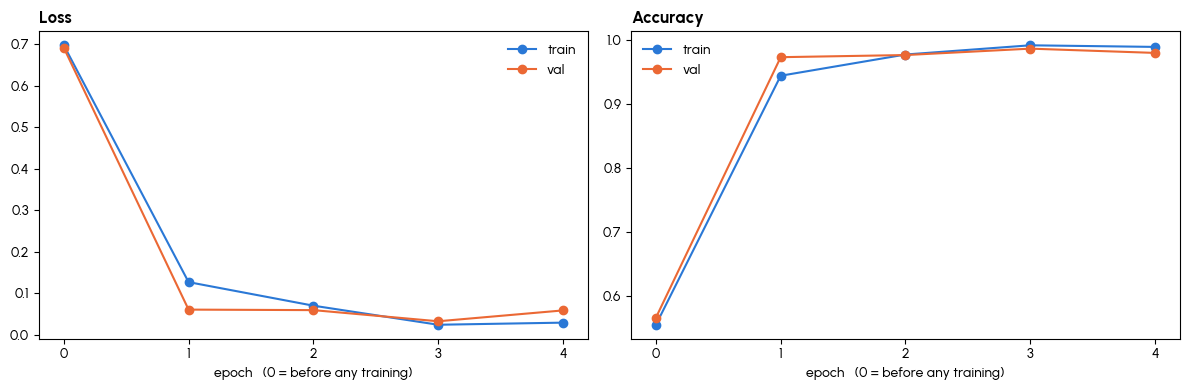

In [70]:
history = np.array(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, cols, title in ((axes[0], (0, 2), "Loss"), (axes[1], (1, 3), "Accuracy")):
    for col, split, colour in zip(cols, ("train", "val"), ("#2a78d6", "#eb6834")):
        ax.plot(history[:, col], color=colour, marker="o", label=split)
    ax.set_title(title, loc="left", weight="bold")
    ax.set_xlabel("epoch   (0 = before any training)")
    ax.set_xticks(range(len(history)))
    ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 9. Predicting on an unseen cat

- This photo comes from the `test` split — no weight was ever updated on it

**From probabilities to an answer**

$$
\hat{y} \;=\; \arg\max_k \; p_k
$$

- $\hat{y}$ (*y-hat*) — the prediction; the hat means *estimated*
- $\arg\max$ — not the biggest value itself, but *which position* holds it. $\arg\max\,(0.881,\ 0.119) = 0$, so: cat

**Only the gap between the two scores matters**

Divide one softmax formula by the other — the shared bottom line cancels out:

$$
\frac{p_{\text{cat}}}{p_{\text{dog}}}
\;=\; \frac{e^{z_{\text{cat}}} \,/\, \left(e^{z_{\text{cat}}} + e^{z_{\text{dog}}}\right)}{e^{z_{\text{dog}}} \,/\, \left(e^{z_{\text{cat}}} + e^{z_{\text{dog}}}\right)}
\;=\; \frac{e^{z_{\text{cat}}}}{e^{z_{\text{dog}}}}
\;=\; e^{\,z_{\text{cat}} - z_{\text{dog}}}
$$

- $p_{\text{cat}} / p_{\text{dog}}$ is the **odds**: how many times more likely cat is than dog
- With $z = (2,\ 0)$ the odds are $e^{2} = 7.39$ — and indeed $0.881 / 0.119 = 7.4$
- Add 100 to both scores and the gap, and so the answer, is unchanged
- The code below prints the real gap and odds for the unseen photo

true label 0 (cat)

  cat  logit  +4.1236    probability 0.999910
  dog  logit  -5.1960    probability 0.000090

logit gap  +9.3197  ->  odds 11,155 : 1  on cat
prediction 0 (cat)   confidence 99.9910%   correct


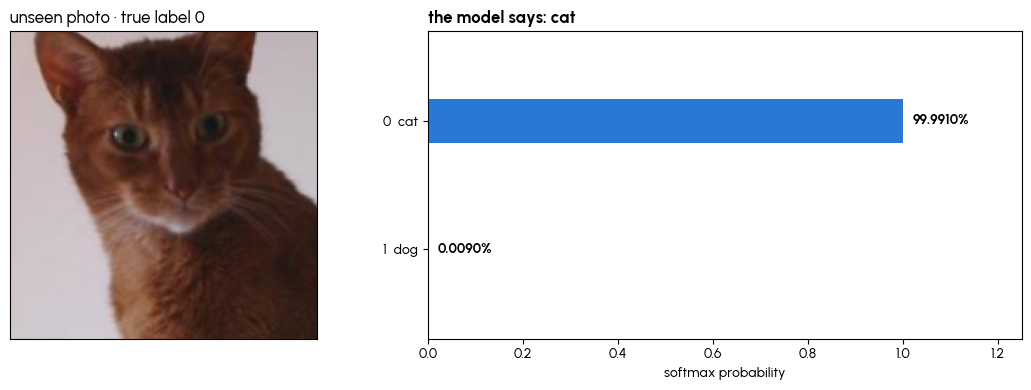

In [71]:
UNSEEN = int(np.flatnonzero(np.array([to_binary(y) for y in test_ds._labels]) == 0)[7])
image, label = test_ds[UNSEEN]

model.eval()
with torch.no_grad():
    logits = model(image[None].to(DEVICE))[0].cpu()
probs = logits.softmax(0)

print(f"true label {label} ({CLASSES[label]})\n")
for k, name in enumerate(CLASSES):
    print(f"  {name:<4} logit {logits[k]:>+8.4f}    probability {probs[k]:.6f}")
pred = int(probs.argmax())
gap  = (logits[pred] - logits[1 - pred]).item()
print(f"\nlogit gap  {gap:+.4f}  ->  odds {np.exp(gap):,.0f} : 1  on {CLASSES[pred]}")
print(f"prediction {pred} ({CLASSES[pred]})   confidence {probs[pred]:.4%}   "
      f"{'correct' if pred == label else 'WRONG'}")

mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
std  = torch.tensor([0.229, 0.224, 0.225])[:, None, None]

fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1, 1.4]})
ax_img.imshow((image * std + mean).clamp(0, 1).permute(1, 2, 0))
ax_img.set_title(f"unseen photo · true label {label}", loc="left")
ax_img.set_xticks([]); ax_img.set_yticks([])
ax_bar.barh([1, 0], [probs[0].item(), probs[1].item()], height=.35, color=["#2a78d6", "#eb6834"])
ax_bar.set_yticks([1, 0], [f"0  {CLASSES[0]}", f"1  {CLASSES[1]}"])
for y, k in ((1, 0), (0, 1)):
    ax_bar.text(probs[k] + .02, y, f"{probs[k]:.4%}", va="center", weight="bold")
ax_bar.set_xlim(0, 1.25); ax_bar.set_ylim(-.7, 1.7); ax_bar.set_xlabel("softmax probability")
ax_bar.set_title(f"the model says: {CLASSES[pred]}", loc="left", weight="bold")
plt.tight_layout(); plt.show()

**One photo proves nothing** — here is the whole held-out split.

In [72]:
subset = Subset(test_ds, range(0, len(test_ds), 4))              # ~900 unseen photos
probs_all, true_all = [], []
with torch.no_grad():
    for images, labels in DataLoader(subset, batch_size=64):
        probs_all.append(model(images.to(DEVICE)).softmax(1).cpu())
        true_all.append(labels)

probs_all, true_all = torch.cat(probs_all), torch.cat(true_all)
pred_all = probs_all.argmax(1)

print(f"{len(true_all):,} held-out photos   accuracy {(pred_all == true_all).float().mean():.2%}")
for k, name in enumerate(CLASSES):
    mask = true_all == k
    print(f"  was {name:<4} {mask.sum():>4} photos   recall {(pred_all[mask] == k).float().mean():.1%}")

918 held-out photos   accuracy 98.91%
  was cat   296 photos   recall 98.0%
  was dog   622 photos   recall 99.4%
